# 소주제 3 — 폐기 위험도 예측 (Binary Classification)

> **목표:** 유통기한 내 재고 소진 가능 여부를 예측하는 이진 분류 모델을 구축하여, 폐기 위험 제품을 사전 식별한다.
>
> - **타겟 변수:** `Waste_Risk` (파생변수 — 원본 데이터에 없음, Feature Engineering으로 직접 생성)
> - **모델:** Logistic Regression · SVM (RBF) · XGBoost Classifier
> - **평가:** Precision · Recall · F1-Score (Risk 클래스) · ROC-AUC · PR-AUC
> - **담당:** 권효중

> **★ 추가 심화 분석:**
> 7. Days_To_Expiry Ablation Study — DTE 지배력 정량 검증 ★
> 8. Learning Curve — 과적합 진단 ★
> 9. Permutation Importance — 피처 중요도 교차검증 ★
> 10. Calibration Curve + Brier Score — 예측 확률 신뢰도 검정 ★


## 0. 라이브러리 임포트 & 환경 설정

In [1]:
import pandas as pd
import numpy as np
import csv
import json
import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 (Malgun Gothic — matplotlib 내장 폰트)
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

# ML
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import shap
import joblib

SEED = 42
np.random.seed(SEED)

# 출력 디렉토리
import os
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

print("✅ 라이브러리 & 환경 설정 완료")
print(f"  한글 폰트: {plt.rcParams['font.family']}")

Matplotlib is building the font cache; this may take a moment.


✅ 라이브러리 & 환경 설정 완료
  한글 폰트: ['Malgun Gothic']


## 1. 데이터 로드 & 기본 확인

In [2]:
csv_path = '../data/Supply Chain Inventory Management Grocery Industry/Inventory Management E-Grocery - InventoryData.csv'
df = pd.read_csv(csv_path)
print(f"데이터 크기: {df.shape}")
print(f"행: {df.shape[0]:,}개, 열: {df.shape[1]}개")
df.head(3)

데이터 크기: (1000, 37)
행: 1,000개, 열: 37개


,SKU_ID,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,...,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,SKU0001,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,...,"2,39","5,00","70,68%",FIFO,In Stock,0,2025-06-26,"-7,14%","95,67%",NaN
1,SKU0002,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,...,"3,34","12,00","84,61%",FEFO,Low Stock,4,2025-08-12,"2,15%","86,00%",NaN
2,SKU0003,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,...,"2,26","11,00","85,36%",FIFO,Expiring Soon,-5,2025-08-13,"6,85%","87,64%",NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

In [4]:
df.describe()

,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Forecast_Next_30d,Reorder_Point,Safety_Stock,Lead_Time_Days,Count_Variance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,91.541000,231.563000,50.302000,38.742000,1.168000,0.8120,332.218940,152.797633,58.473000,4.030000,0.199000
std,52.475308,201.988781,50.106162,42.765761,1.295938,0.9206,301.358418,163.056230,66.051556,2.983622,2.708641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,1.000000,1.001000,2.000000,1.000000,-7.000000
25%,46.000000,81.000000,15.000000,10.000000,0.000000,0.0000,2.577250,46.000000,19.000000,2.000000,-1.000000
50%,95.000000,180.000000,35.000000,24.000000,1.000000,1.0000,288.000000,98.000000,36.500000,3.000000,0.000000
75%,138.000000,320.000000,68.000000,53.000000,2.000000,1.0000,572.500000,196.000000,70.250000,5.000000,2.000000
max,180.000000,977.000000,363.000000,310.000000,7.000000,4.0000,994.000000,954.000000,624.000000,14.000000,9.000000


In [5]:
# 결측치 확인
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'결측 수': missing, '비율(%)': missing_pct})
miss_df[miss_df['결측 수'] > 0]

,결측 수,비율(%)
Notes,834,83.4


## 2. 데이터 전처리

> **⚠️ 인도네시아 로케일 형식 주의:**
> - 쉼표(`,`)가 **소수점**, 마침표(`.`)가 **천단위 구분자**로 사용됨
> - 예: `2.142,90` → 2142.90 / `$5,81` → 5.81
> - 일부 컬럼에 천단위+소수점 혼합값 존재 → **반드시 3단계 변환 필요**

In [6]:
# ──────────────────────────────────────────────
# 1. 인도네시아 로케일 숫자 변환
#    ⚠️ 천단위 마침표(.) 제거 → 쉼표 소수점(,) → 마침표(.) 순서 엄수!
#    단순 replace(',', '.')만 하면 '2.142,90' 같은 혼합값에서 ValueError 발생
# ──────────────────────────────────────────────
comma_decimal_cols = [
    'Avg_Daily_Sales', 'Days_of_Inventory',
    'SKU_Churn_Rate', 'Order_Frequency_per_month'
]
for col in comma_decimal_cols:
    df[col] = (df[col].astype(str)
               .str.replace('.', '', regex=False)   # 1) 천단위 구분 마침표 제거
               .str.replace(',', '.', regex=False)   # 2) 쉼표 소수점 → 마침표
               .astype(float))                        # 3) float 변환

print("✅ 인도네시아 로케일 숫자 변환 완료")
for col in comma_decimal_cols:
    print(f"  {col}: mean={df[col].mean():.4f}, min={df[col].min():.4f}, max={df[col].max():.4f}")

✅ 인도네시아 로케일 숫자 변환 완료
  Avg_Daily_Sales: mean=26.5828, min=1.0100, max=99.5000
  Days_of_Inventory: mean=9.9931, min=0.0000, max=21.9500
  SKU_Churn_Rate: mean=6.3291, min=1.3700, max=2142.9000
  Order_Frequency_per_month: mean=9.8130, min=1.0000, max=46.0000


In [7]:
# ──────────────────────────────────────────────
# 1-1. Reorder_Point 특수 처리
#      10행에서 천단위 마침표 오파싱 (예: '1.170' → pandas 1.17 → 실제 1170)
#      raw CSV에서 원본 값 재추출
# ──────────────────────────────────────────────
raw_rp = []
with open(csv_path) as f:
    reader = csv.DictReader(f)
    for row in reader:
        raw_rp.append(row['Reorder_Point'])

df['Reorder_Point'] = [int(v.replace('.', '')) if '.' in v else int(v) for v in raw_rp]
print(f"✅ Reorder_Point 수정 완료: mean={df['Reorder_Point'].mean():.1f}, "
      f"min={df['Reorder_Point'].min()}, max={df['Reorder_Point'].max()}")

✅ Reorder_Point 수정 완료: mean=165.4, min=3, max=1870


In [8]:
# ──────────────────────────────────────────────
# 2. 금액 컬럼 변환 ($, 천단위 구분 마침표, 쉼표 소수점)
# ──────────────────────────────────────────────
money_cols = ['Unit_Cost_USD', 'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD']
for col in money_cols:
    df[col] = (df[col].astype(str)
               .str.replace('$', '', regex=False)
               .str.replace('.', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))
print("✅ 금액 컬럼 변환 완료")

# ──────────────────────────────────────────────
# 3. 퍼센트 컬럼 변환
# ──────────────────────────────────────────────
pct_cols = ['Supplier_OnTime_Pct', 'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct']
for col in pct_cols:
    df[col] = (df[col].astype(str)
               .str.replace('%', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))
print("✅ 퍼센트 컬럼 변환 완료")

# ──────────────────────────────────────────────
# 4. 날짜 컬럼 파싱
# ──────────────────────────────────────────────
for col in ['Received_Date', 'Last_Purchase_Date', 'Expiry_Date', 'Audit_Date']:
    df[col] = pd.to_datetime(df[col])
print("✅ 날짜 컬럼 파싱 완료")

# 전처리 결과 요약
print(f"\n{'='*60}")
print(f"전처리 완료: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"수치형: {df.select_dtypes(include=[np.number]).shape[1]}열")
print(f"범주형: {df.select_dtypes(include=['object']).shape[1]}열")
print(f"날짜형: {df.select_dtypes(include=['datetime64']).shape[1]}열")

✅ 금액 컬럼 변환 완료
✅ 퍼센트 컬럼 변환 완료
✅ 날짜 컬럼 파싱 완료

전처리 완료: 1,000행 × 37열
수치형: 21열
범주형: 12열
날짜형: 4열


## 3. 타겟 변수 생성 — 핵심 Feature Engineering

> **소주제 3의 가장 중요한 차별점:** 타겟 변수(`Waste_Risk`)가 원본 데이터에 없으며, 도메인 지식 기반으로 직접 설계한다.
>
> **폐기 위험 판단 논리:**
> - `Days_To_Deplete` = 현재 판매 속도로 재고를 소진하는 데 걸리는 일수 (`QOH / ADS`)
> - `Remaining_Shelf_Days` = 유통기한까지 남은 일수 (`Expiry_Date - reference_date`)
> - **소진 일수 > 잔여 유통기한** → 유통기한 내 소진 불가 → **폐기 위험(Risk=1)**

In [9]:
# ──────────────────────────────────────────────
# 1. Days_To_Expiry (입고일 기준 유통기한 전체 일수) — 피처로 사용
# ──────────────────────────────────────────────
df['Days_To_Expiry'] = (df['Expiry_Date'] - df['Received_Date']).dt.days
print(f"Days_To_Expiry: mean={df['Days_To_Expiry'].mean():.1f}, "
      f"min={df['Days_To_Expiry'].min()}, max={df['Days_To_Expiry'].max()}")

# ──────────────────────────────────────────────
# 2. Stock_Age_Days 기준점 검증
#    → Stock_Age_Days = (2025-09-09 - Received_Date) 확인
# ──────────────────────────────────────────────
sa_check = (pd.Timestamp('2025-09-09') - df['Received_Date']).dt.days
match_count = (sa_check == df['Stock_Age_Days']).sum()
print(f"\nStock_Age_Days 기준점 검증:")
print(f"  (2025-09-09 - Received_Date) == Stock_Age_Days 일치: {match_count}/{len(df)}행")
print(f"  → 데이터 생성 기준일: 2025-09-09 확인됨")

# ──────────────────────────────────────────────
# 3. reference_date 설정 (분석 기준일 = 데이터 생성 다음 날)
# ──────────────────────────────────────────────
reference_date = pd.Timestamp('2025-09-10')
print(f"\nreference_date: {reference_date.date()} (데이터 생성일 + 1일)")

# ──────────────────────────────────────────────
# 4. Remaining_Shelf_Days (유통기한 잔여일)
# ──────────────────────────────────────────────
df['Remaining_Shelf_Days'] = (df['Expiry_Date'] - reference_date).dt.days
expired = (df['Remaining_Shelf_Days'] < 0).sum()
print(f"\nRemaining_Shelf_Days: mean={df['Remaining_Shelf_Days'].mean():.1f}")
print(f"  이미 유통기한 초과(< 0): {expired}건 → 자동으로 Risk 분류")

# Remaining_Shelf_Days = DTE - SA - 1 검증
rsd_reconstructed = df['Days_To_Expiry'] - df['Stock_Age_Days'] - 1
rsd_match = (rsd_reconstructed == df['Remaining_Shelf_Days']).sum()
print(f"  RSD = DTE - SA - 1 일치: {rsd_match}/{len(df)}행")

# ──────────────────────────────────────────────
# 5. Days_To_Deplete (재고 소진 예상 일수)
# ──────────────────────────────────────────────
ads_zero = (df['Avg_Daily_Sales'] == 0).sum()
print(f"\nAvg_Daily_Sales == 0인 행: {ads_zero}건 (min={df['Avg_Daily_Sales'].min():.2f})")
df['Days_To_Deplete'] = df['Quantity_On_Hand'] / df['Avg_Daily_Sales']

# ──────────────────────────────────────────────
# 6. ★ Waste_Risk 타겟 생성 ★
# ──────────────────────────────────────────────
df['Waste_Risk'] = (df['Days_To_Deplete'] > df['Remaining_Shelf_Days']).astype(int)

print(f"\n{'='*60}")
print("★ Waste_Risk 타겟 변수 생성 완료 ★")
print(f"{'='*60}")
print(df['Waste_Risk'].value_counts().to_string())
print()
print(df['Waste_Risk'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}").to_string())

Days_To_Expiry: mean=570.4, min=2, max=1824

Stock_Age_Days 기준점 검증:
  (2025-09-09 - Received_Date) == Stock_Age_Days 일치: 1000/1000행
  → 데이터 생성 기준일: 2025-09-09 확인됨

reference_date: 2025-09-10 (데이터 생성일 + 1일)

Remaining_Shelf_Days: mean=477.8
  이미 유통기한 초과(< 0): 406건 → 자동으로 Risk 분류
  RSD = DTE - SA - 1 일치: 1000/1000행

Avg_Daily_Sales == 0인 행: 0건 (min=1.01)

★ Waste_Risk 타겟 변수 생성 완료 ★
Waste_Risk
0    575
1    425

Waste_Risk
0    57.5%
1    42.5%


### 타겟 생성 논리 해석

| 상황 | Days_To_Deplete | Remaining_Shelf_Days | 판단 | Waste_Risk |
|------|:---:|:---:|------|:---:|
| 소진 일수 > 유통기한 잔여일 | 60일 | 40일 | 유통기한 전에 다 못 팜 → **폐기 위험** | **1 (Risk)** |
| 소진 일수 ≤ 유통기한 잔여일 | 20일 | 40일 | 유통기한 내 소진 가능 → **안전** | **0 (Safe)** |
| 이미 유통기한 초과 | - | < 0 | 이미 만료 → **폐기 위험** | **1 (Risk)** |

In [10]:
# 카테고리별 Waste_Risk 비율 확인
cat_risk = pd.crosstab(df['Category'], df['Waste_Risk'], normalize='index')
cat_risk.columns = ['Safe', 'Risk']
cat_risk['Risk비율'] = cat_risk['Risk'].apply(lambda x: f"{x:.1%}")
cat_risk = cat_risk.sort_values('Risk', ascending=False)
print("카테고리별 폐기 위험 비율:")
print(cat_risk.to_string())
print()

# 카테고리별 유통기한(DTE) 평균
dte_by_cat = df.groupby('Category')['Days_To_Expiry'].mean().sort_values()
print("카테고리별 Days_To_Expiry 평균 (오름차순):")
for cat, dte in dte_by_cat.items():
    risk_pct = cat_risk.loc[cat, 'Risk'] * 100
    label = "🔴 부패성" if dte < 30 else "🟢 비부패성"
    print(f"  {cat:20s}: DTE 평균 {dte:8.1f}일  Risk {risk_pct:5.1f}%  {label}")

카테고리별 폐기 위험 비율:
                   Safe      Risk  Risk비율
Category                                 
Bakery         0.000000  1.000000  100.0%
Fresh Produce  0.000000  1.000000  100.0%
Seafood        0.000000  1.000000  100.0%
Meat           0.011494  0.988506   98.9%
Dairy          0.020833  0.979167   97.9%
Beverages      1.000000  0.000000    0.0%
Frozen         1.000000  0.000000    0.0%
Household      1.000000  0.000000    0.0%
Pantry         1.000000  0.000000    0.0%
Personal Care  1.000000  0.000000    0.0%

카테고리별 Days_To_Expiry 평균 (오름차순):
  Bakery              : DTE 평균      4.5일  Risk 100.0%  🔴 부패성
  Seafood             : DTE 평균      7.1일  Risk 100.0%  🔴 부패성
  Fresh Produce       : DTE 평균      8.5일  Risk 100.0%  🔴 부패성
  Meat                : DTE 평균     12.7일  Risk  98.9%  🔴 부패성
  Dairy               : DTE 평균     18.2일  Risk  97.9%  🔴 부패성
  Frozen              : DTE 평균    269.8일  Risk   0.0%  🟢 비부패성
  Household           : DTE 평균   1092.0일  Risk   0.0%  🟢 비부패성
  Pantry          

## 4. EDA (탐색적 데이터 분석)

### 4.1 Waste_Risk 클래스 분포

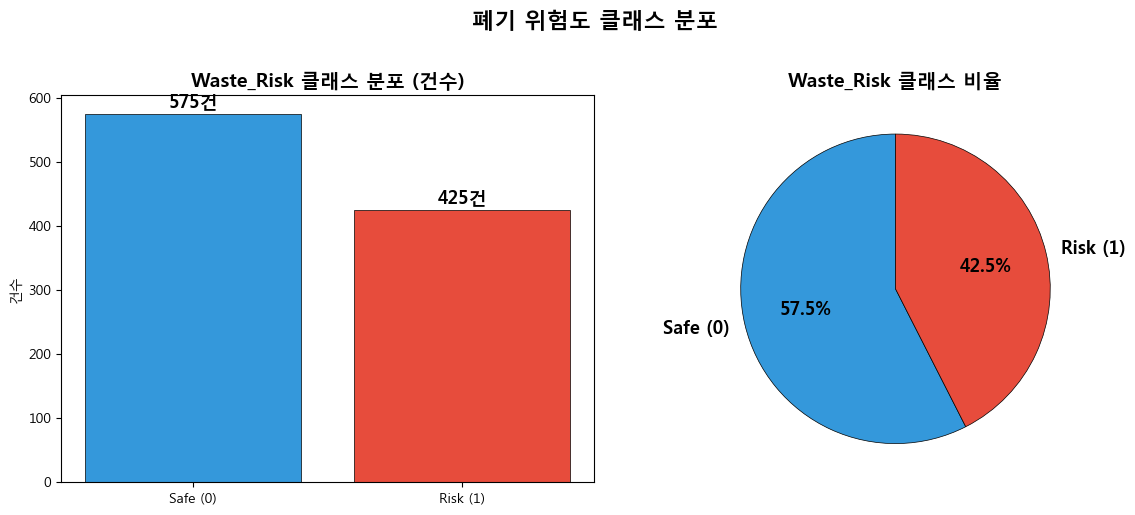

✅ 저장: waste_risk_distribution_s3.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 카운트
counts = df['Waste_Risk'].value_counts().sort_index()
labels = ['Safe (0)', 'Risk (1)']
colors = ['#3498db', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f"{v}건", ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Waste_Risk 클래스 분포 (건수)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('건수')

# 비율
pcts = df['Waste_Risk'].value_counts(normalize=True).sort_index() * 100
axes[1].pie(pcts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Waste_Risk 클래스 비율', fontsize=14, fontweight='bold')

plt.suptitle('폐기 위험도 클래스 분포', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/waste_risk_distribution_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: waste_risk_distribution_s3.png")

### 4.2 카테고리별 폐기 위험 비율 (핵심)

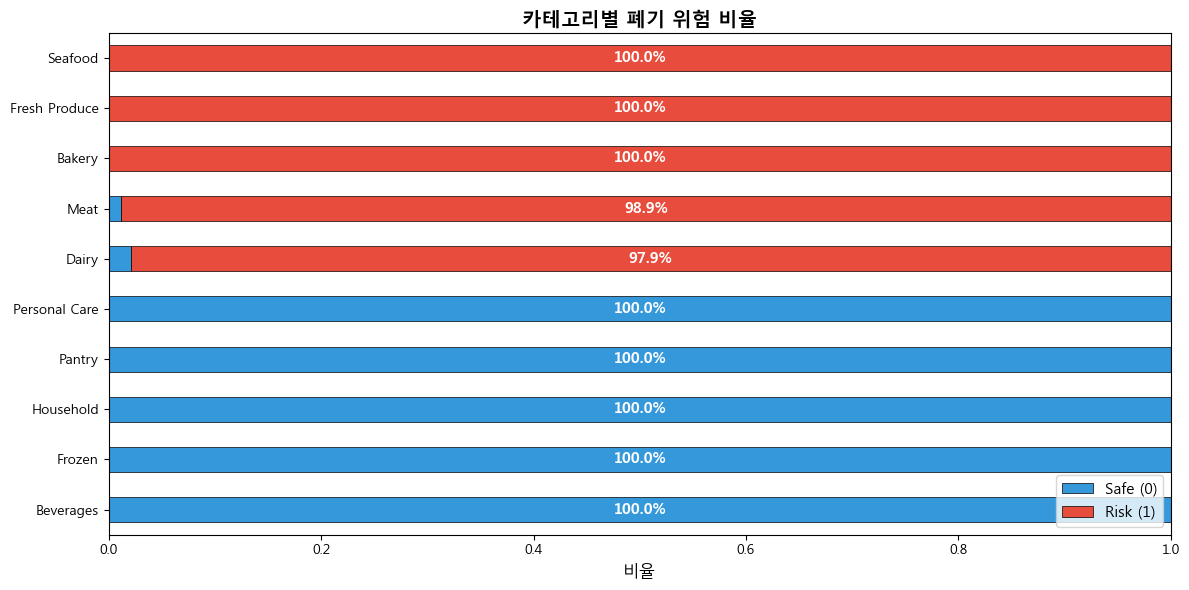

✅ 저장: category_risk_ratio_s3.png


In [12]:
cat_risk_ct = pd.crosstab(df['Category'], df['Waste_Risk'])
cat_risk_ct.columns = ['Safe', 'Risk']
cat_risk_pct = cat_risk_ct.div(cat_risk_ct.sum(axis=1), axis=0)
cat_risk_pct = cat_risk_pct.sort_values('Risk', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
cat_risk_pct.plot(kind='barh', stacked=True, color=['#3498db', '#e74c3c'],
                  edgecolor='black', linewidth=0.5, ax=ax)

for i, (idx, row) in enumerate(cat_risk_pct.iterrows()):
    risk_pct = row['Risk'] * 100
    if risk_pct > 5:
        ax.text(row['Safe'] + row['Risk']/2, i, f"{risk_pct:.1f}%",
                ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    safe_pct = row['Safe'] * 100
    if safe_pct > 5:
        ax.text(row['Safe']/2, i, f"{safe_pct:.1f}%",
                ha='center', va='center', fontweight='bold', fontsize=11, color='white')

ax.set_xlabel('비율', fontsize=12)
ax.set_ylabel('')
ax.set_title('카테고리별 폐기 위험 비율', fontsize=14, fontweight='bold')
ax.legend(['Safe (0)', 'Risk (1)'], loc='lower right', fontsize=11)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/figures/category_risk_ratio_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: category_risk_ratio_s3.png")

### 4.3 카테고리별 Days_To_Expiry 분포 — 부패성 vs 비부패성

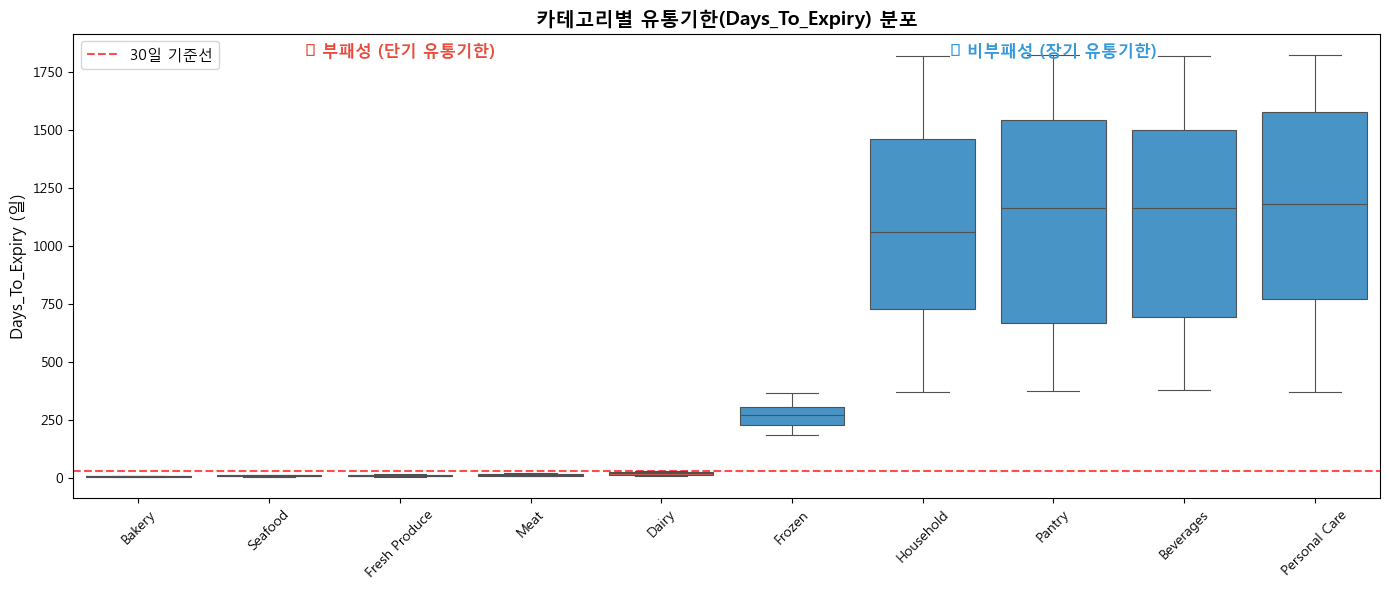

✅ 저장: category_dte_distribution_s3.png


In [13]:
# 카테고리를 DTE 평균 기준으로 정렬
cat_order = df.groupby('Category')['Days_To_Expiry'].mean().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
palette = {cat: '#e74c3c' if df[df['Category']==cat]['Days_To_Expiry'].mean() < 30
           else '#3498db' for cat in cat_order}

sns.boxplot(data=df, x='Category', y='Days_To_Expiry', order=cat_order,
            palette=palette, ax=ax, linewidth=0.8)

ax.axhline(y=30, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='30일 기준선')
ax.set_title('카테고리별 유통기한(Days_To_Expiry) 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Days_To_Expiry (일)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=11)

# 부패성/비부패성 구분 텍스트
ax.text(2, ax.get_ylim()[1]*0.95, '🔴 부패성 (단기 유통기한)',
        fontsize=12, fontweight='bold', color='#e74c3c', ha='center')
ax.text(7, ax.get_ylim()[1]*0.95, '🟢 비부패성 (장기 유통기한)',
        fontsize=12, fontweight='bold', color='#3498db', ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/category_dte_distribution_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: category_dte_distribution_s3.png")

### 4.4 ABC 등급별 폐기 위험 비율

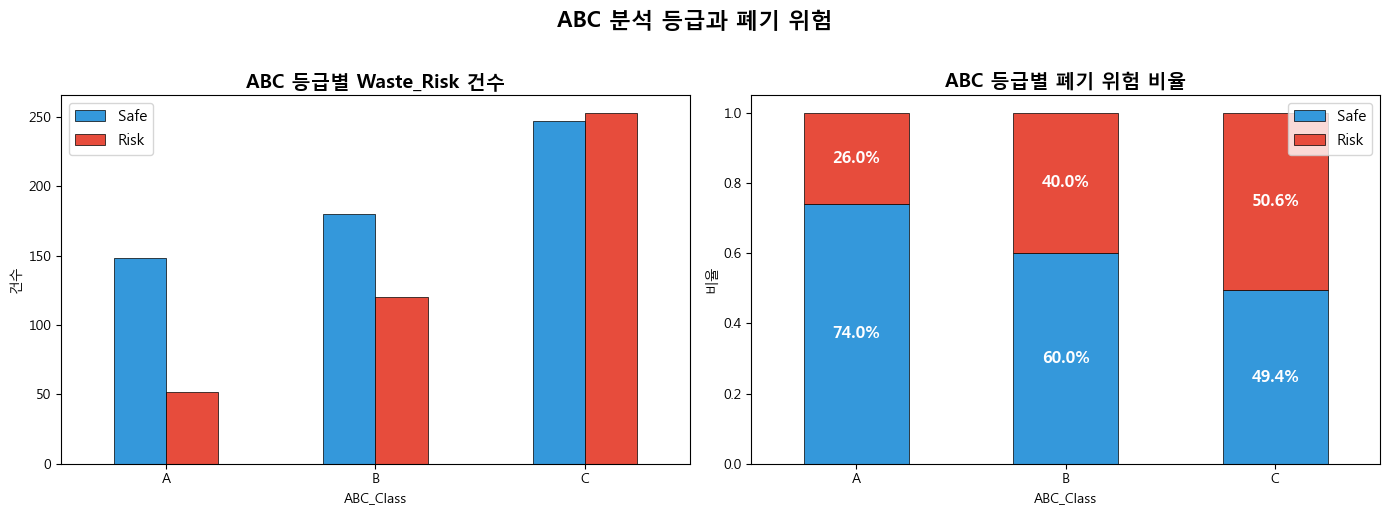

✅ 저장: abc_risk_ratio_s3.png


In [14]:
abc_risk = pd.crosstab(df['ABC_Class'], df['Waste_Risk'])
abc_risk.columns = ['Safe', 'Risk']
abc_risk_pct = abc_risk.div(abc_risk.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 건수
abc_risk.plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black',
              linewidth=0.5, ax=axes[0], rot=0)
axes[0].set_title('ABC 등급별 Waste_Risk 건수', fontsize=14, fontweight='bold')
axes[0].set_ylabel('건수')
axes[0].legend(['Safe', 'Risk'], fontsize=11)

# 비율
abc_risk_pct.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'],
                  edgecolor='black', linewidth=0.5, ax=axes[1], rot=0)
for i, (idx, row) in enumerate(abc_risk_pct.iterrows()):
    axes[1].text(i, row['Safe']/2, f"{row['Safe']*100:.1f}%",
                 ha='center', va='center', fontweight='bold', color='white', fontsize=12)
    axes[1].text(i, row['Safe'] + row['Risk']/2, f"{row['Risk']*100:.1f}%",
                 ha='center', va='center', fontweight='bold', color='white', fontsize=12)
axes[1].set_title('ABC 등급별 폐기 위험 비율', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율')
axes[1].legend(['Safe', 'Risk'], fontsize=11)

plt.suptitle('ABC 분석 등급과 폐기 위험', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/abc_risk_ratio_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: abc_risk_ratio_s3.png")

### 4.5 폐기 위험 여부별 주요 피처 분포

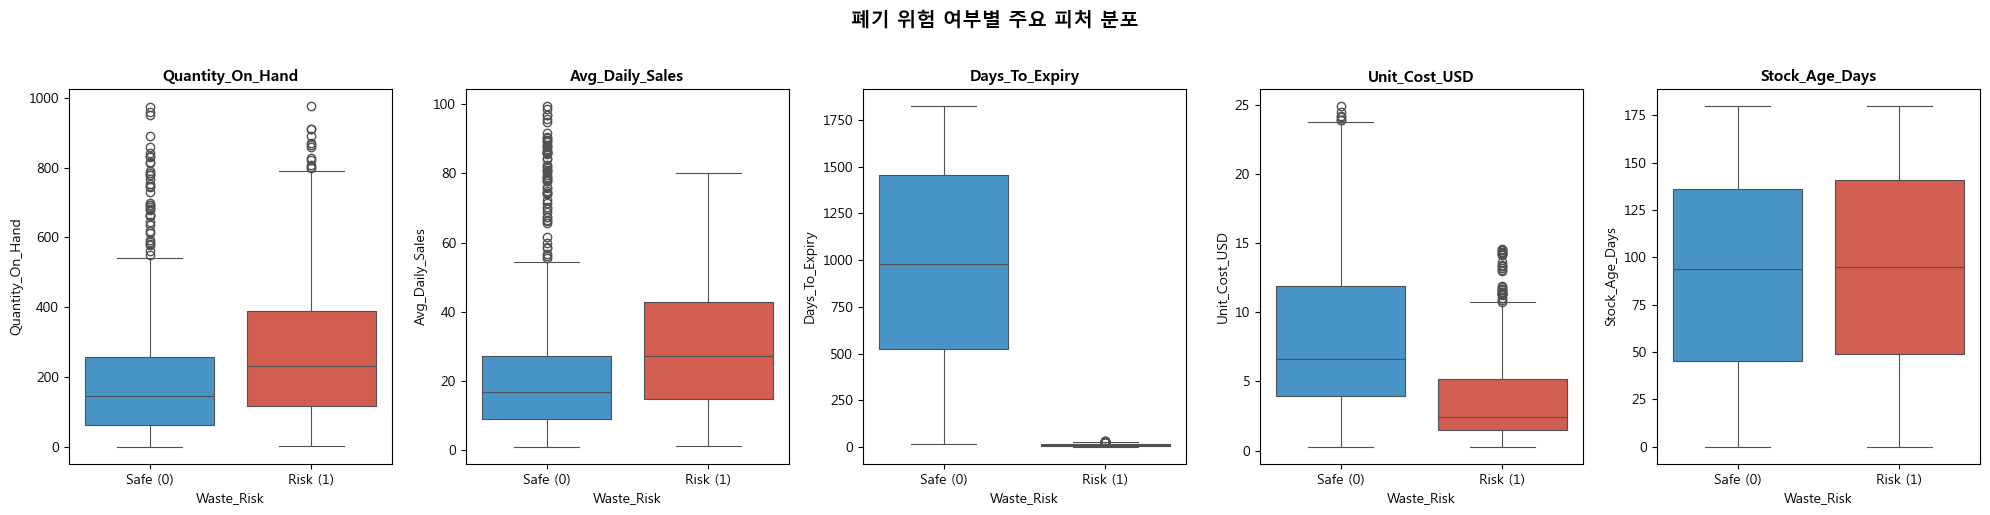

✅ 저장: risk_feature_boxplots_s3.png


In [15]:
feat_cols = ['Quantity_On_Hand', 'Avg_Daily_Sales', 'Days_To_Expiry',
             'Unit_Cost_USD', 'Stock_Age_Days']

fig, axes = plt.subplots(1, len(feat_cols), figsize=(20, 5))

for i, col in enumerate(feat_cols):
    sns.boxplot(data=df, x='Waste_Risk', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], linewidth=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Waste_Risk')
    axes[i].set_xticklabels(['Safe (0)', 'Risk (1)'])

plt.suptitle('폐기 위험 여부별 주요 피처 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/risk_feature_boxplots_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: risk_feature_boxplots_s3.png")

### 4.6 Remaining_Shelf_Days vs Days_To_Deplete 산점도 (핵심)

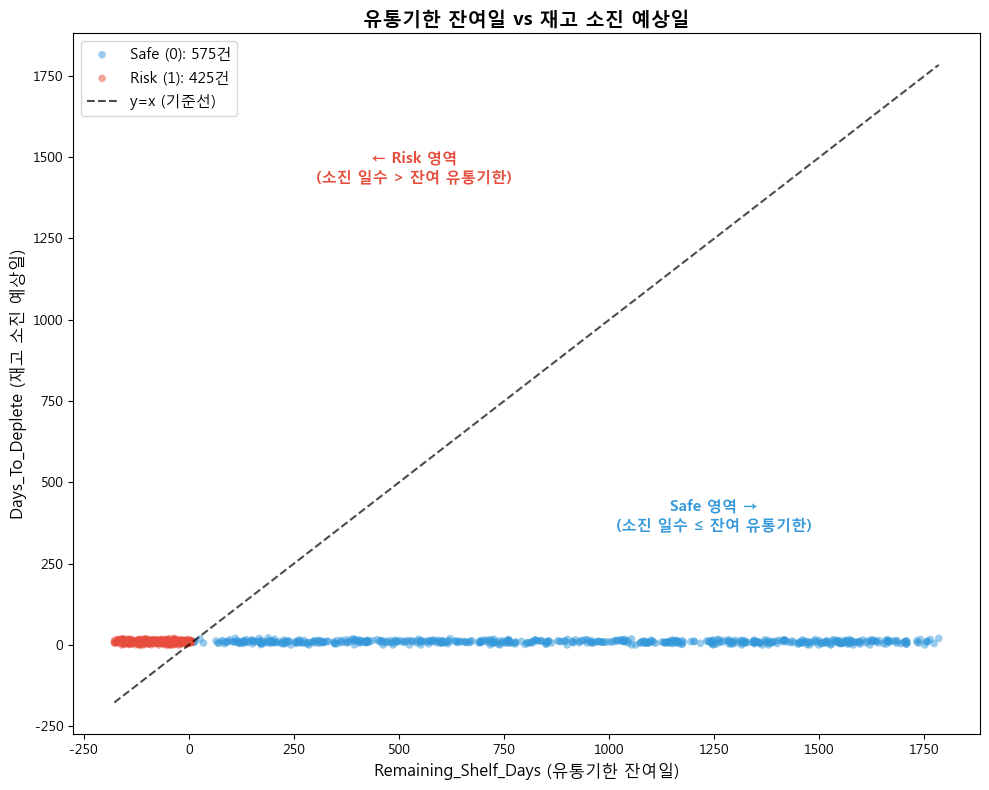

✅ 저장: expiry_vs_deplete_scatter_s3.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

safe = df[df['Waste_Risk'] == 0]
risk = df[df['Waste_Risk'] == 1]

ax.scatter(safe['Remaining_Shelf_Days'], safe['Days_To_Deplete'],
           c='#3498db', alpha=0.5, s=30, label=f'Safe (0): {len(safe)}건', edgecolors='none')
ax.scatter(risk['Remaining_Shelf_Days'], risk['Days_To_Deplete'],
           c='#e74c3c', alpha=0.5, s=30, label=f'Risk (1): {len(risk)}건', edgecolors='none')

# 기준선 (y=x): 이 선 위가 Risk
max_val = max(df['Remaining_Shelf_Days'].max(), df['Days_To_Deplete'].max())
min_val = min(df['Remaining_Shelf_Days'].min(), 0)
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5,
        alpha=0.7, label='y=x (기준선)')

ax.set_xlabel('Remaining_Shelf_Days (유통기한 잔여일)', fontsize=12)
ax.set_ylabel('Days_To_Deplete (재고 소진 예상일)', fontsize=12)
ax.set_title('유통기한 잔여일 vs 재고 소진 예상일', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# 영역 표시
ax.text(max_val*0.3, max_val*0.8, '← Risk 영역\n(소진 일수 > 잔여 유통기한)',
        fontsize=11, color='#e74c3c', fontweight='bold', ha='center')
ax.text(max_val*0.7, max_val*0.2, 'Safe 영역 →\n(소진 일수 ≤ 잔여 유통기한)',
        fontsize=11, color='#3498db', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/expiry_vs_deplete_scatter_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: expiry_vs_deplete_scatter_s3.png")

### 4.7 피처 간 상관관계 히트맵

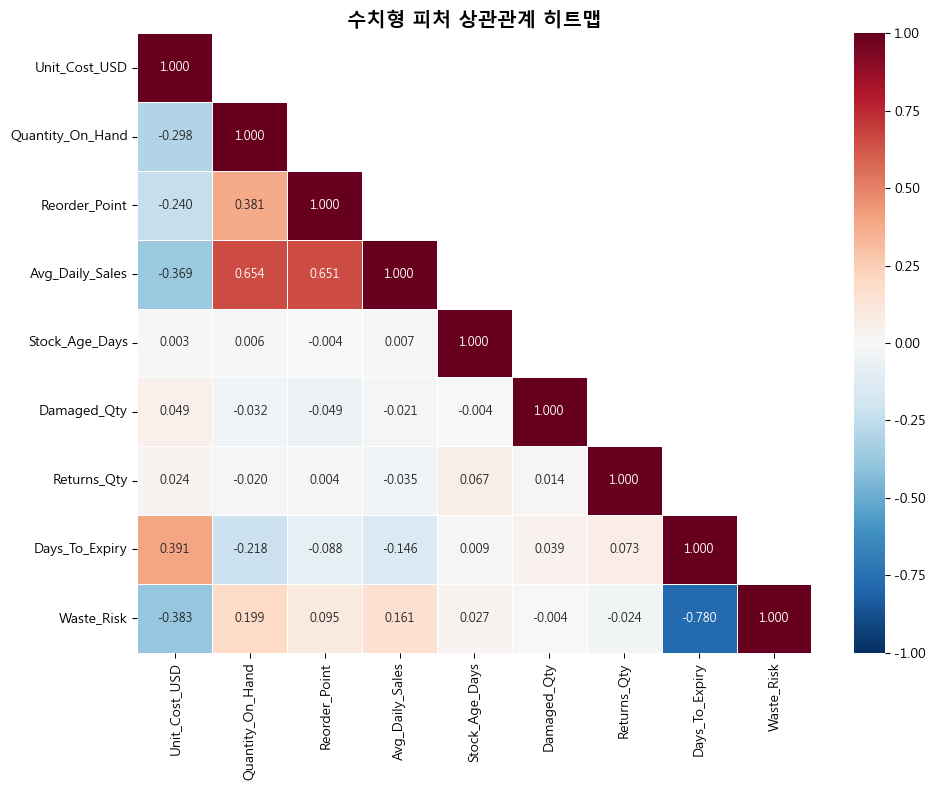

✅ 저장: correlation_heatmap_s3.png

Waste_Risk와의 상관계수 (절대값 기준 정렬):
  Days_To_Expiry      : -0.7798  ███████████████████████
  Unit_Cost_USD       : -0.3834  ███████████
  Quantity_On_Hand    : +0.1990  █████
  Avg_Daily_Sales     : +0.1608  ████
  Reorder_Point       : +0.0946  ██
  Stock_Age_Days      : +0.0270  
  Returns_Qty         : -0.0244  
  Damaged_Qty         : -0.0037  


In [17]:
numeric_features = ['Unit_Cost_USD', 'Quantity_On_Hand', 'Reorder_Point',
                    'Avg_Daily_Sales', 'Stock_Age_Days', 'Damaged_Qty',
                    'Returns_Qty', 'Days_To_Expiry', 'Waste_Risk']

corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'fontsize': 9})
ax.set_title('수치형 피처 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: correlation_heatmap_s3.png")

# Waste_Risk와의 상관 정리
wr_corr = corr['Waste_Risk'].drop('Waste_Risk').sort_values(key=abs, ascending=False)
print("\nWaste_Risk와의 상관계수 (절대값 기준 정렬):")
for feat, val in wr_corr.items():
    bar = '█' * int(abs(val) * 30)
    print(f"  {feat:20s}: {val:+.4f}  {bar}")

## 5. 데이터 누수(Data Leakage) 진단

> ⚠️ **소주제 1, 2에서 발견된 데이터 누수 패턴이 소주제 3에도 존재한다.**
> 피처 선택 전 반드시 진단하여 모델 신뢰성을 확보한다.

### 5.1 Days_of_Inventory ≈ Days_To_Deplete 검증

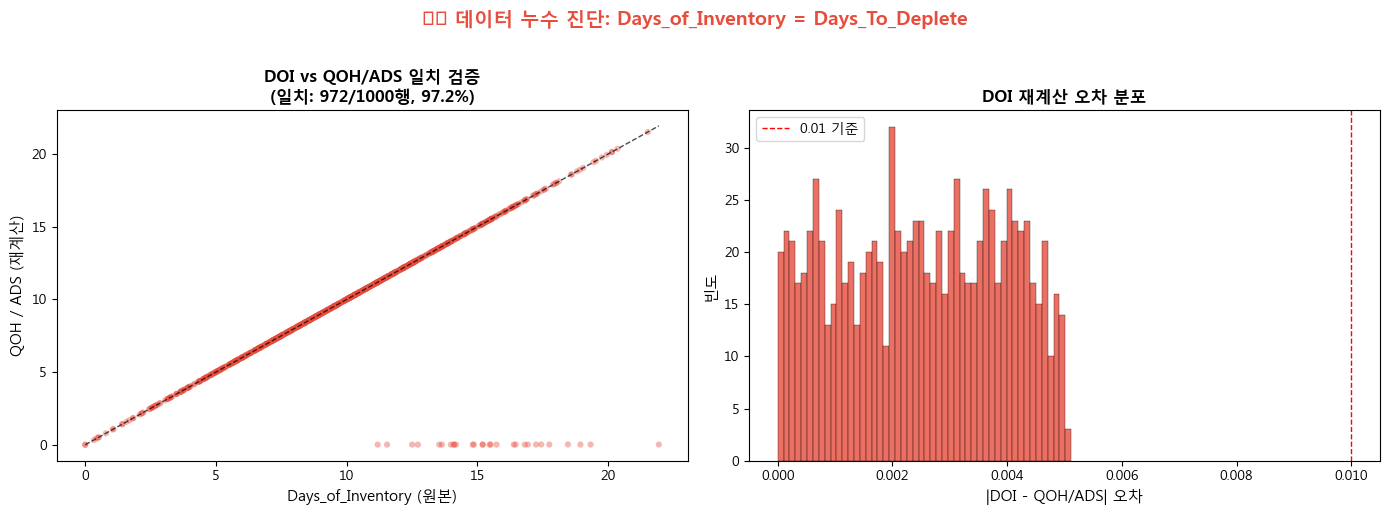


⚠️ DATA LEAKAGE 확인
  Days_of_Inventory ≈ QOH / ADS 일치: 972/1000행 (97.2%)
  → DOI = Days_To_Deplete → 타겟(Waste_Risk) 산출의 직접 좌변!
  → 결론: Days_of_Inventory를 피처에서 반드시 제거


In [18]:
# DOI ≈ QOH / ADS = DTD 검증
doi_reconstructed = df['Quantity_On_Hand'] / df['Avg_Daily_Sales']
doi_diff = (df['Days_of_Inventory'] - doi_reconstructed).abs()

exact_match = (doi_diff < 0.01).sum()
close_match = (doi_diff < 1.0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산점도
axes[0].scatter(df['Days_of_Inventory'], doi_reconstructed,
                alpha=0.4, s=20, c='#e74c3c', edgecolors='none')
max_v = max(df['Days_of_Inventory'].max(), doi_reconstructed.max())
axes[0].plot([0, max_v], [0, max_v], 'k--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Days_of_Inventory (원본)', fontsize=11)
axes[0].set_ylabel('QOH / ADS (재계산)', fontsize=11)
axes[0].set_title(f'DOI vs QOH/ADS 일치 검증\n(일치: {exact_match}/1000행, {exact_match/10:.1f}%)',
                  fontsize=12, fontweight='bold')

# 오차 분포
axes[1].hist(doi_diff[doi_diff < 5], bins=50, color='#e74c3c', edgecolor='black',
             linewidth=0.3, alpha=0.8)
axes[1].set_xlabel('|DOI - QOH/ADS| 오차', fontsize=11)
axes[1].set_ylabel('빈도', fontsize=11)
axes[1].set_title('DOI 재계산 오차 분포', fontsize=12, fontweight='bold')
axes[1].axvline(x=0.01, color='red', linestyle='--', linewidth=1, label='0.01 기준')
axes[1].legend()

plt.suptitle('⚠️ 데이터 누수 진단: Days_of_Inventory = Days_To_Deplete',
             fontsize=14, fontweight='bold', color='#e74c3c', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/data_leakage_diagnosis_s3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"⚠️ DATA LEAKAGE 확인")
print(f"  Days_of_Inventory ≈ QOH / ADS 일치: {exact_match}/1000행 ({exact_match/10:.1f}%)")
print(f"  → DOI = Days_To_Deplete → 타겟(Waste_Risk) 산출의 직접 좌변!")
print(f"  → 결론: Days_of_Inventory를 피처에서 반드시 제거")
print(f"{'='*60}")

### 5.2 카테고리별 구조적 분석 — 왜 모든 모델이 ~99% 정확도인가?

> **핵심 발견:** `Category`만으로 Random Forest Accuracy **99.0%** 달성.
> 이는 데이터 누수가 아닌 **식료품 유통의 구조적 특성** 반영:
> - 부패성 제품(유통기한 ≤ 30일): 거의 모두 폐기 위험
> - 비부패성 제품(유통기한 ≥ 270일): 폐기 위험 없음
> - 유통기한이 짧은 제품의 폐기 위험이 높은 것은 **자명한 도메인 지식**

In [19]:
# 카테고리별 DTE 통계 + Risk 비율 종합 테이블
cat_summary = df.groupby('Category').agg(
    DTE_mean=('Days_To_Expiry', 'mean'),
    DTE_median=('Days_To_Expiry', 'median'),
    DTE_min=('Days_To_Expiry', 'min'),
    DTE_max=('Days_To_Expiry', 'max'),
    Risk_count=('Waste_Risk', 'sum'),
    Total=('Waste_Risk', 'count')
).assign(Risk_pct=lambda x: (x['Risk_count'] / x['Total'] * 100).round(1))
cat_summary = cat_summary.sort_values('DTE_mean')
cat_summary['분류'] = cat_summary['DTE_mean'].apply(lambda x: '🔴 부패성' if x < 30 else '🟢 비부패성')

print("카테고리별 유통기한 & 폐기 위험 종합 분석:")
print(cat_summary.to_string())
print()
print("→ 결론: Category(유통기한 구조)가 Waste_Risk를 거의 결정하는 구조적 패턴")
print("→ 이는 데이터 누수가 아닌 도메인 특성이므로 피처 사용 정당")

카테고리별 유통기한 & 폐기 위험 종합 분석:
                  DTE_mean  DTE_median  DTE_min  DTE_max  Risk_count  Total  Risk_pct      분류
Category                                                                                     
Bakery            4.507246         5.0        2        7          69     69     100.0   🔴 부패성
Seafood           7.060606         8.0        3       10          66     66     100.0   🔴 부패성
Fresh Produce     8.472727         8.0        3       14         110    110     100.0   🔴 부패성
Meat             12.735632        12.0        5       21          86     87      98.9   🔴 부패성
Dairy            18.156250        18.0        7       30          94     96      97.9   🔴 부패성
Frozen          269.813953       270.5      184      365           0     86       0.0  🟢 비부패성
Household      1091.990291      1061.0      369     1818           0    103       0.0  🟢 비부패성
Pantry         1100.445255      1164.0      372     1821           0    137       0.0  🟢 비부패성
Beverages      1100.633333      11

### 5.3 최종 피처셋 결정

| 변수 | 처리 | 이유 |
|------|------|------|
| **Days_of_Inventory** | ❌ **제거** | DOI ≈ DTD — 타겟 산출 직접 변수 (Data Leakage) |
| Days_To_Deplete | ❌ 제거 | 타겟 생성 중간 변수 (좌변) |
| Remaining_Shelf_Days | ❌ 제거 | 타겟 생성 중간 변수 (우변) |
| Waste_Risk | 🎯 타겟 | y로 분리 |
| Days_To_Expiry | ✅ **유지** | 입고 시 알 수 있는 독립 정보 (관측 가능) |
| Stock_Age_Days | ✅ **유지** | 재고 보유 기간 (관측 가능) |
| Quantity_On_Hand | ✅ **유지** | 현재 재고량 (관측 가능) |
| Avg_Daily_Sales | ✅ **유지** | 판매 속도 (관측 가능) |

## 6. 피처/타겟 분리 & Train/Test Split

In [20]:
# ──────────────────────────────────────────────
# 1. 피처 선택 (누수 변수 제외)
# ──────────────────────────────────────────────
numeric_features = [
    'Unit_Cost_USD', 'Quantity_On_Hand', 'Reorder_Point',
    'Avg_Daily_Sales', 'Stock_Age_Days', 'Damaged_Qty',
    'Returns_Qty', 'Days_To_Expiry'
]

# 범주형 인코딩
df_model = df.copy()

# Category One-Hot (Bakery as baseline → drop_first)
cat_dummies = pd.get_dummies(df_model['Category'], prefix='Cat', drop_first=True)
# ABC_Class One-Hot (A as baseline)
abc_dummies = pd.get_dummies(df_model['ABC_Class'], prefix='ABC', drop_first=True)
# FIFO_FEFO 이진 인코딩
df_model['FIFO_FEFO_encoded'] = (df_model['FIFO_FEFO'] == 'FEFO').astype(int)

# 피처 결합
X = pd.concat([df_model[numeric_features], cat_dummies, abc_dummies,
               df_model[['FIFO_FEFO_encoded']]], axis=1)
y = df_model['Waste_Risk']

# 제외 확인
excluded = ['Days_of_Inventory', 'Days_To_Deplete', 'Remaining_Shelf_Days']
for col in excluded:
    assert col not in X.columns, f"⚠️ {col}이 피처에 포함됨!"
print(f"✅ 누수 변수 제외 확인: {excluded}")

print(f"\n피처 매트릭스 X: {X.shape}")
print(f"타겟 벡터 y: {y.shape}")
print(f"총 피처 수: {X.shape[1]}개")
print(f"  수치형: {len(numeric_features)}개")
print(f"  Category (One-Hot): {cat_dummies.shape[1]}개")
print(f"  ABC_Class (One-Hot): {abc_dummies.shape[1]}개")
print(f"  FIFO_FEFO: 1개")
print(f"\n피처 목록:\n  {list(X.columns)}")

✅ 누수 변수 제외 확인: ['Days_of_Inventory', 'Days_To_Deplete', 'Remaining_Shelf_Days']

피처 매트릭스 X: (1000, 20)
타겟 벡터 y: (1000,)
총 피처 수: 20개
  수치형: 8개
  Category (One-Hot): 9개
  ABC_Class (One-Hot): 2개
  FIFO_FEFO: 1개

피처 목록:
  ['Unit_Cost_USD', 'Quantity_On_Hand', 'Reorder_Point', 'Avg_Daily_Sales', 'Stock_Age_Days', 'Damaged_Qty', 'Returns_Qty', 'Days_To_Expiry', 'Cat_Beverages', 'Cat_Dairy', 'Cat_Fresh Produce', 'Cat_Frozen', 'Cat_Household', 'Cat_Meat', 'Cat_Pantry', 'Cat_Personal Care', 'Cat_Seafood', 'ABC_B', 'ABC_C', 'FIFO_FEFO_encoded']


In [21]:
# ──────────────────────────────────────────────
# 2. Train/Test Split (80:20, stratified)
# ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train set: {X_train.shape[0]}행 ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:  {X_test.shape[0]}행 ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTrain 클래스 분포:")
print(y_train.value_counts().to_string())
print(f"\nTest 클래스 분포:")
print(y_test.value_counts().to_string())

# ──────────────────────────────────────────────
# 3. StandardScaler 적용
# ──────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n✅ StandardScaler 적용 완료")

# 피처명 보존용 DataFrame
feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

Train set: 800행 (80%)
Test set:  200행 (20%)

Train 클래스 분포:
Waste_Risk
0    460
1    340

Test 클래스 분포:
Waste_Risk
0    115
1     85

✅ StandardScaler 적용 완료


## 7. 모델 학습 & 평가

### 7.1 Default 모델 학습 (3종)

In [22]:
# 클래스 비율 (scale_pos_weight용)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"클래스 비율 — Safe(0): {neg_count}, Risk(1): {pos_count}")
print(f"scale_pos_weight = {spw:.4f}")

# ──────────────────────────────────────────────
# Default 모델 정의
# ──────────────────────────────────────────────
default_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=SEED, use_label_encoder=False
    )
}

# 학습 & 평가
default_results = {}
for name, model in default_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    gap = train_acc - test_acc

    default_results[name] = {
        'Train Acc': train_acc, 'Test Acc': test_acc,
        'Precision(Risk)': prec, 'Recall(Risk)': rec,
        'F1(Risk)': f1, 'ROC-AUC': auc, 'Gap': gap,
        'model': model
    }
    print(f"[Default] {name:25s} — Test Acc: {test_acc:.4f}, "
          f"Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}, Gap: {gap:.4f}")

print("\n✅ Default 모델 학습 완료")

클래스 비율 — Safe(0): 460, Risk(1): 340
scale_pos_weight = 1.3529
[Default] Logistic Regression       — Test Acc: 0.9900, Recall: 1.0000, F1: 0.9884, AUC: 0.9964, Gap: 0.0088
[Default] SVM (RBF)                 — Test Acc: 0.9900, Recall: 1.0000, F1: 0.9884, AUC: 0.9961, Gap: 0.0088
[Default] XGBoost                   — Test Acc: 0.9900, Recall: 1.0000, F1: 0.9884, AUC: 0.9996, Gap: 0.0088

✅ Default 모델 학습 완료


### 7.2 교차검증 (5-Fold Stratified CV)

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("5-Fold Stratified Cross-Validation:")
print(f"{'모델':25s} {'Mean Acc':>10s} {'Std':>8s} {'Mean F1':>10s}")
print("-" * 60)

cv_results = {}
for name, model_info in default_results.items():
    model = model_info['model']
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')

    cv_results[name] = {
        'CV_Acc_Mean': acc_scores.mean(),
        'CV_Acc_Std': acc_scores.std(),
        'CV_F1_Mean': f1_scores.mean(),
        'CV_F1_Std': f1_scores.std()
    }
    print(f"{name:25s} {acc_scores.mean():10.4f} {acc_scores.std():8.4f} "
          f"{f1_scores.mean():10.4f}")

5-Fold Stratified Cross-Validation:
모델                          Mean Acc      Std    Mean F1
------------------------------------------------------------
Logistic Regression           0.9988   0.0025     0.9985


SVM (RBF)                     0.9975   0.0031     0.9971


XGBoost                       0.9963   0.0050     0.9956


### 7.3 하이퍼파라미터 튜닝 (GridSearchCV)

In [24]:
# ──────────────────────────────────────────────
# Logistic Regression 튜닝
# ──────────────────────────────────────────────
lr_params = {'C': [0.01, 0.1, 1, 10, 100]}
lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    lr_params, cv=cv, scoring='f1', n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
print(f"[LR Tuned] Best params: {lr_grid.best_params_}, Best F1: {lr_grid.best_score_:.4f}")

# ──────────────────────────────────────────────
# SVM 튜닝
# ──────────────────────────────────────────────
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}
svm_grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED),
    svm_params, cv=cv, scoring='f1', n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
print(f"[SVM Tuned] Best params: {svm_grid.best_params_}, Best F1: {svm_grid.best_score_:.4f}")

# ──────────────────────────────────────────────
# XGBoost 튜닝
# ──────────────────────────────────────────────
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8, 0.9]
}
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                  random_state=SEED, use_label_encoder=False),
    xgb_params, cv=cv, scoring='f1', n_jobs=-1
)
xgb_grid.fit(X_train_scaled, y_train)
print(f"[XGB Tuned] Best params: {xgb_grid.best_params_}, Best F1: {xgb_grid.best_score_:.4f}")

[LR Tuned] Best params: {'C': 0.01}, Best F1: 0.9985


[SVM Tuned] Best params: {'C': 0.1, 'gamma': 'scale'}, Best F1: 0.9985


[XGB Tuned] Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}, Best F1: 0.9971


### 7.4 Tuned 모델 평가

In [25]:
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'SVM (RBF)': svm_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    gap = train_acc - test_acc

    tuned_results[name] = {
        'Train Acc': train_acc, 'Test Acc': test_acc,
        'Precision(Risk)': prec, 'Recall(Risk)': rec,
        'F1(Risk)': f1, 'ROC-AUC': auc, 'Gap': gap,
        'model': model
    }
    print(f"[Tuned] {name:25s} — Test Acc: {test_acc:.4f}, "
          f"Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}, Gap: {gap:.4f}")

[Tuned] Logistic Regression       — Test Acc: 0.9900, Recall: 1.0000, F1: 0.9884, AUC: 0.9932, Gap: 0.0088
[Tuned] SVM (RBF)                 — Test Acc: 0.9900, Recall: 1.0000, F1: 0.9884, AUC: 0.9916, Gap: 0.0088
[Tuned] XGBoost                   — Test Acc: 0.9900, Recall: 1.0000, F1: 0.9884, AUC: 0.9999, Gap: 0.0088


### 7.5 Default vs Tuned 비교

Default vs Tuned 성능 비교:


,모델,Default Acc,Tuned Acc,Acc 변화,Default F1,Tuned F1,F1 변화,Default AUC,Tuned AUC,AUC 변화
0,Logistic Regression,0.99,0.99,0.0,0.9884,0.9884,0.0,0.9964,0.9932,-0.0032
1,SVM (RBF),0.99,0.99,0.0,0.9884,0.9884,0.0,0.9961,0.9916,-0.0045
2,XGBoost,0.99,0.99,0.0,0.9884,0.9884,0.0,0.9996,0.9999,0.0003


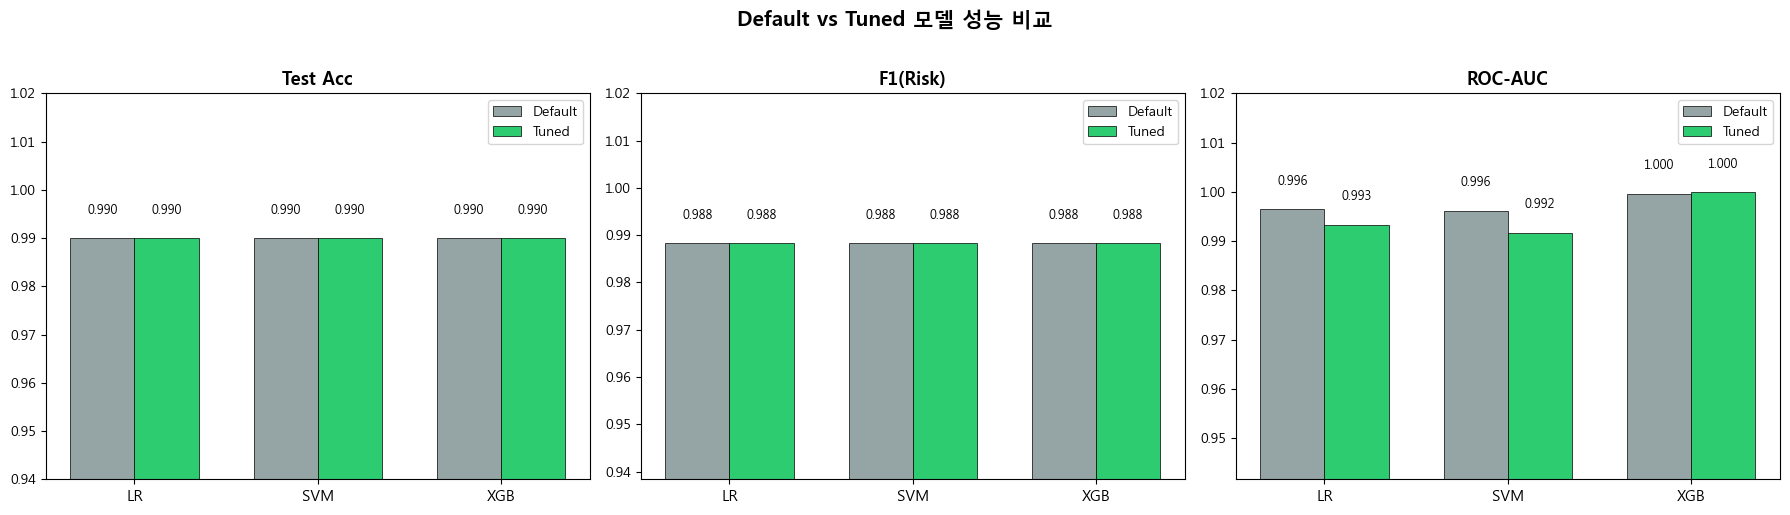

✅ 저장: model_comparison_default_vs_tuned_s3.png


In [26]:
# 비교 테이블
comparison_data = []
for name in default_results:
    d = default_results[name]
    t = tuned_results[name]
    comparison_data.append({
        '모델': name,
        'Default Acc': d['Test Acc'],
        'Tuned Acc': t['Test Acc'],
        'Acc 변화': t['Test Acc'] - d['Test Acc'],
        'Default F1': d['F1(Risk)'],
        'Tuned F1': t['F1(Risk)'],
        'F1 변화': t['F1(Risk)'] - d['F1(Risk)'],
        'Default AUC': d['ROC-AUC'],
        'Tuned AUC': t['ROC-AUC'],
        'AUC 변화': t['ROC-AUC'] - d['ROC-AUC']
    })

comp_df = pd.DataFrame(comparison_data)
print("Default vs Tuned 성능 비교:")
display(comp_df.round(4))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('Test Acc', 'Default Acc', 'Tuned Acc'),
           ('F1(Risk)', 'Default F1', 'Tuned F1'),
           ('ROC-AUC', 'Default AUC', 'Tuned AUC')]
model_names = comp_df['모델'].values

for i, (metric_name, dcol, tcol) in enumerate(metrics):
    x = np.arange(len(model_names))
    w = 0.35
    axes[i].bar(x - w/2, comp_df[dcol], w, label='Default', color='#95a5a6', edgecolor='black', linewidth=0.5)
    axes[i].bar(x + w/2, comp_df[tcol], w, label='Tuned', color='#2ecc71', edgecolor='black', linewidth=0.5)
    axes[i].set_title(metric_name, fontsize=13, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['LR', 'SVM', 'XGB'], fontsize=11)
    axes[i].legend(fontsize=10)
    axes[i].set_ylim(min(comp_df[dcol].min(), comp_df[tcol].min()) - 0.05, 1.02)

    for j in range(len(model_names)):
        axes[i].text(j - w/2, comp_df[dcol].iloc[j] + 0.005,
                     f"{comp_df[dcol].iloc[j]:.3f}", ha='center', fontsize=9)
        axes[i].text(j + w/2, comp_df[tcol].iloc[j] + 0.005,
                     f"{comp_df[tcol].iloc[j]:.3f}", ha='center', fontsize=9)

plt.suptitle('Default vs Tuned 모델 성능 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison_default_vs_tuned_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: model_comparison_default_vs_tuned_s3.png")

### 7.6 최종 모델 성능 비교 종합표

최종 모델 성능 비교 (Tuned, Recall 기준 정렬):


,모델,Train Acc,Test Acc,CV Acc,Precision(Risk),Recall(Risk),F1(Risk),ROC-AUC,Gap
0,Logistic Regression,0.9988,0.99,0.9988,0.977,1.0,0.9884,0.9932,0.0088
1,SVM (RBF),0.9988,0.99,0.9975,0.977,1.0,0.9884,0.9916,0.0088
2,XGBoost,0.9988,0.99,0.9962,0.977,1.0,0.9884,0.9999,0.0088


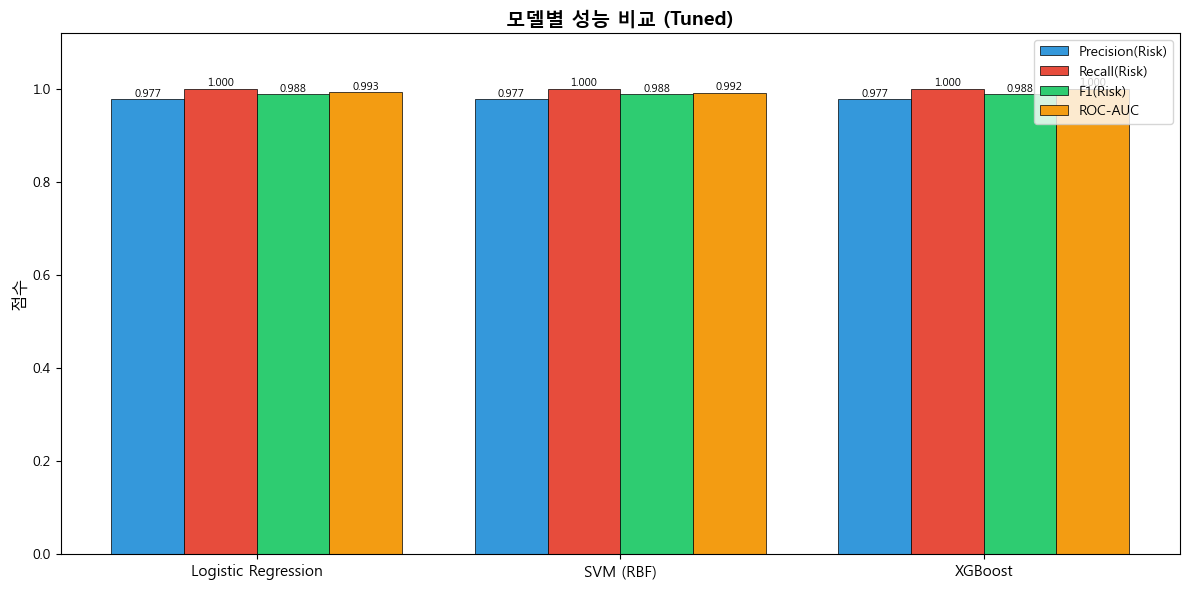

✅ 저장: model_comparison_s3.png


In [27]:
# 최종 결과 테이블 (Tuned 기준)
final_data = []
for name in tuned_results:
    r = tuned_results[name]
    c = cv_results.get(name, {})
    final_data.append({
        '모델': name,
        'Train Acc': r['Train Acc'],
        'Test Acc': r['Test Acc'],
        'CV Acc': c.get('CV_Acc_Mean', None),
        'Precision(Risk)': r['Precision(Risk)'],
        'Recall(Risk)': r['Recall(Risk)'],
        'F1(Risk)': r['F1(Risk)'],
        'ROC-AUC': r['ROC-AUC'],
        'Gap': r['Gap']
    })

final_df = pd.DataFrame(final_data).sort_values('Recall(Risk)', ascending=False)
print("최종 모델 성능 비교 (Tuned, Recall 기준 정렬):")
display(final_df.round(4))

# 막대 차트
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Precision(Risk)', 'Recall(Risk)', 'F1(Risk)', 'ROC-AUC']
x = np.arange(len(final_df))
width = 0.2
colors_bar = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i*width, final_df[metric].values, width,
                  label=metric, color=colors_bar[i], edgecolor='black', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(final_df['모델'].values, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('점수', fontsize=12)
ax.set_title('모델별 성능 비교 (Tuned)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: model_comparison_s3.png")

### 7.7 Days_To_Expiry 지배력 검증 (Ablation Study) ★> **목적:** DTE 제거 시 성능 변화를 측정하여, 단일 피처 의존도를 정량화한다.> DTE는 상관 -0.78로 압도적이지만, Category One-Hot이 유통기한 정보를 내포하므로 보완 가능성을 확인한다.

Days_To_Expiry 위치: 인덱스 7



=== DTE Ablation Study 결과 ===


,Model,Scenario,F1,Recall,Acc
LR Full,LR,Full,0.988372,1.0,0.99
LR No-DTE,LR,No-DTE,0.988372,1.0,0.99
RF Full,RF,Full,0.988372,1.0,0.99
RF No-DTE,RF,No-DTE,0.988372,1.0,0.99


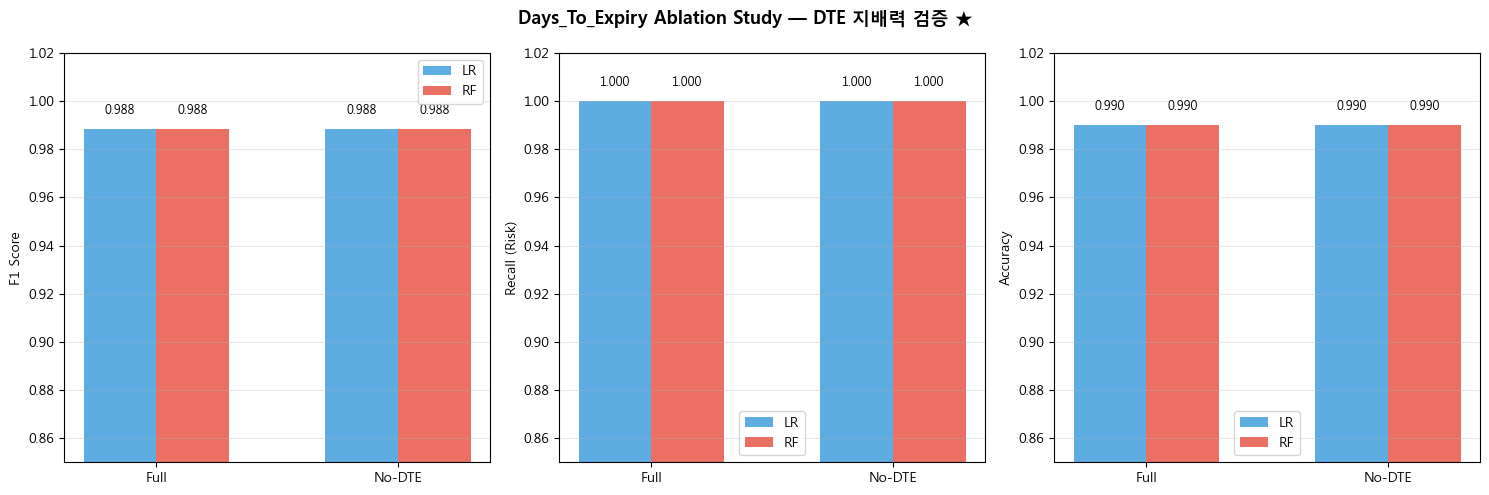


ΔF1 (Full → No-DTE):
  LR: +0.0000
  RF: +0.0000

→ RF: DTE 제거해도 성능 유지 — Category One-Hot이 유통기한 정보 보완


In [28]:
# ── Ablation Study: DTE 제거 시 성능 변화 ──
from sklearn.ensemble import RandomForestClassifier

# 현재 피처 목록에서 DTE 인덱스 확인
feature_list = feature_names
dte_idx = feature_list.index('Days_To_Expiry')
print(f"Days_To_Expiry 위치: 인덱스 {dte_idx}")

# Full 피처 학습 (LR + RF)
X_train_full = X_train_scaled.copy()
X_test_full = X_test_scaled.copy()

lr_full = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr_full.fit(X_train_full, y_train)
rf_full = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED)
rf_full.fit(X_train_full, y_train)

# DTE 제거 후 학습
X_train_no_dte = np.delete(X_train_scaled, dte_idx, axis=1)
X_test_no_dte = np.delete(X_test_scaled, dte_idx, axis=1)

lr_no_dte = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr_no_dte.fit(X_train_no_dte, y_train)
rf_no_dte = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED)
rf_no_dte.fit(X_train_no_dte, y_train)

# 결과 비교
results_ablation = {
    'LR Full': {
        'F1': f1_score(y_test, lr_full.predict(X_test_full)),
        'Recall': recall_score(y_test, lr_full.predict(X_test_full)),
        'Acc': accuracy_score(y_test, lr_full.predict(X_test_full))
    },
    'LR No-DTE': {
        'F1': f1_score(y_test, lr_no_dte.predict(X_test_no_dte)),
        'Recall': recall_score(y_test, lr_no_dte.predict(X_test_no_dte)),
        'Acc': accuracy_score(y_test, lr_no_dte.predict(X_test_no_dte))
    },
    'RF Full': {
        'F1': f1_score(y_test, rf_full.predict(X_test_full)),
        'Recall': recall_score(y_test, rf_full.predict(X_test_full)),
        'Acc': accuracy_score(y_test, rf_full.predict(X_test_full))
    },
    'RF No-DTE': {
        'F1': f1_score(y_test, rf_no_dte.predict(X_test_no_dte)),
        'Recall': recall_score(y_test, rf_no_dte.predict(X_test_no_dte)),
        'Acc': accuracy_score(y_test, rf_no_dte.predict(X_test_no_dte))
    }
}

ablation_df = pd.DataFrame(results_ablation).T
ablation_df['Scenario'] = ['Full', 'No-DTE', 'Full', 'No-DTE']
ablation_df['Model'] = ['LR', 'LR', 'RF', 'RF']
print("\n=== DTE Ablation Study 결과 ===")
display(ablation_df[['Model', 'Scenario', 'F1', 'Recall', 'Acc']])

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['F1', 'Recall', 'Acc']
metric_labels = ['F1 Score', 'Recall (Risk)', 'Accuracy']

for ax, metric, label in zip(axes, metrics, metric_labels):
    x = np.arange(2)
    width = 0.3
    lr_vals = [results_ablation['LR Full'][metric], results_ablation['LR No-DTE'][metric]]
    rf_vals = [results_ablation['RF Full'][metric], results_ablation['RF No-DTE'][metric]]

    bars1 = ax.bar(x - width/2, lr_vals, width, label='LR', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, rf_vals, width, label='RF', color='#e74c3c', alpha=0.8)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_xticks(x)
    ax.set_xticklabels(['Full', 'No-DTE'])
    ax.set_ylim([0.85, 1.02])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Days_To_Expiry Ablation Study — DTE 지배력 검증 ★', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/dte_ablation_study_s3.png', dpi=150, bbox_inches='tight')
plt.show()

# ΔF1 계산
delta_lr = results_ablation['LR Full']['F1'] - results_ablation['LR No-DTE']['F1']
delta_rf = results_ablation['RF Full']['F1'] - results_ablation['RF No-DTE']['F1']
print(f"\nΔF1 (Full → No-DTE):")
print(f"  LR: {delta_lr:+.4f}")
print(f"  RF: {delta_rf:+.4f}")
if abs(delta_rf) < 0.02:
    print("\n→ RF: DTE 제거해도 성능 유지 — Category One-Hot이 유통기한 정보 보완")
else:
    print("\n→ RF: DTE 제거 시 성능 하락 — DTE 독자적 정보 가치 있음")

### 7.8 Learning Curve (과적합 진단) ★> **목적:** 학습 데이터 크기에 따른 Train/Validation 성능 변화를 추적하여 과적합을 진단한다.> 분류 문제이므로 scoring='f1'을 사용한다.

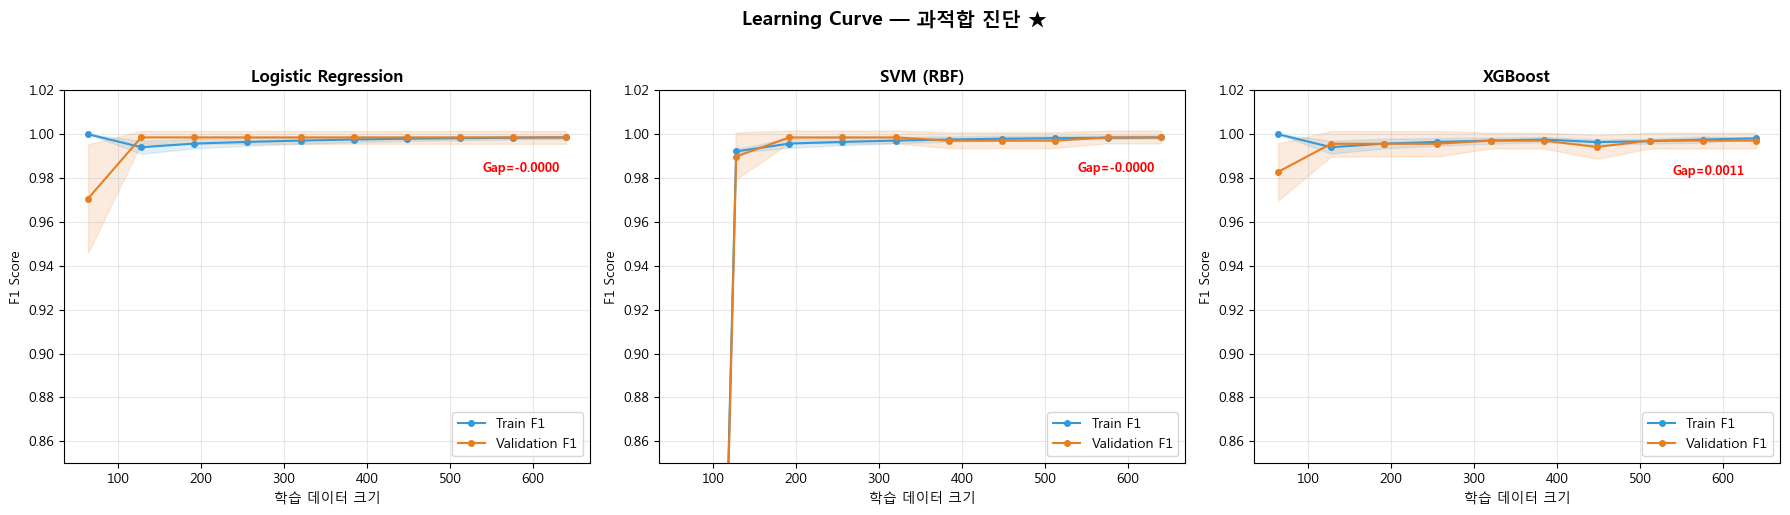


=== Learning Curve 수렴도 요약 ===
  Logistic Regression: Train F1=0.9985, Val F1=0.9985, Gap=-0.0000
  SVM (RBF): Train F1=0.9985, Val F1=0.9985, Gap=-0.0000


  XGBoost: Train F1=0.9982, Val F1=0.9971, Gap=0.0011


In [29]:
# ── Learning Curve: 과적합 진단 ★ ──
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tuned_trained = {
    'Logistic Regression': tuned_models['Logistic Regression'],
    'SVM (RBF)': tuned_models['SVM (RBF)'],
    'XGBoost': tuned_models['XGBoost']
}

for ax, (name, model) in zip(axes, tuned_trained.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=SEED
    )
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#3498db')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#e67e22')
    ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Train F1', markersize=4)
    ax.plot(train_sizes, val_mean, 'o-', color='#e67e22', label='Validation F1', markersize=4)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('학습 데이터 크기')
    ax.set_ylabel('F1 Score')
    ax.legend(loc='lower right')
    ax.set_ylim([0.85, 1.02])
    ax.grid(True, alpha=0.3)

    # Gap 계산
    final_gap = train_mean[-1] - val_mean[-1]
    ax.annotate(f'Gap={final_gap:.4f}', xy=(train_sizes[-1], val_mean[-1]),
                xytext=(-60, -25), textcoords='offset points',
                fontsize=9, color='red', fontweight='bold')

plt.suptitle('Learning Curve — 과적합 진단 ★', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/learning_curve_s3.png', dpi=150, bbox_inches='tight')
plt.show()

# 수렴도 요약
print("\n=== Learning Curve 수렴도 요약 ===")
for name, model in tuned_trained.items():
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=SEED
    )
    gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
    print(f"  {name}: Train F1={train_scores.mean(axis=1)[-1]:.4f}, "
          f"Val F1={val_scores.mean(axis=1)[-1]:.4f}, Gap={gap:.4f}")

## 8. 최적 모델 심층 분석

### 8.1 최적 모델 선정

In [30]:
# Recall(Risk) 기준 최적 모델 선정 (동점 시 F1 기준)
best_name = max(tuned_results, key=lambda k: (
    tuned_results[k]['Recall(Risk)'], tuned_results[k]['F1(Risk)']
))
best_model = tuned_results[best_name]['model']
print(f"★ 최적 모델: {best_name}")
print(f"  Recall(Risk): {tuned_results[best_name]['Recall(Risk)']:.4f}")
print(f"  F1(Risk):     {tuned_results[best_name]['F1(Risk)']:.4f}")
print(f"  ROC-AUC:      {tuned_results[best_name]['ROC-AUC']:.4f}")

★ 최적 모델: Logistic Regression
  Recall(Risk): 1.0000
  F1(Risk):     0.9884
  ROC-AUC:      0.9932


### 8.2 Confusion Matrix

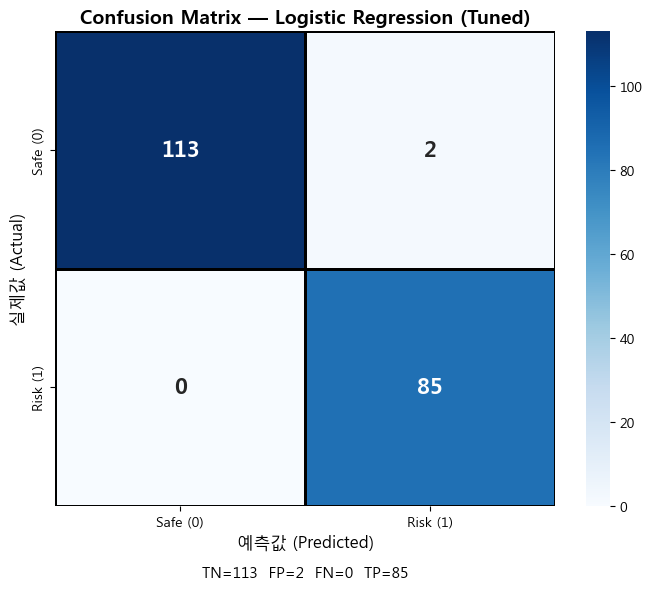

✅ 저장: confusion_matrix_s3.png

Classification Report (Logistic Regression Tuned):
              precision    recall  f1-score   support

    Safe (0)       1.00      0.98      0.99       115
    Risk (1)       0.98      1.00      0.99        85

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [31]:
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Safe (0)', 'Risk (1)'],
            yticklabels=['Safe (0)', 'Risk (1)'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            linewidths=1, linecolor='black')
ax.set_xlabel('예측값 (Predicted)', fontsize=12)
ax.set_ylabel('실제값 (Actual)', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name} (Tuned)', fontsize=14, fontweight='bold')

# 상세 해석
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.15, f"TN={tn}  FP={fp}  FN={fn}  TP={tp}",
        transform=ax.transAxes, ha='center', fontsize=11, style='italic')

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: confusion_matrix_s3.png")
print()
print(f"Classification Report ({best_name} Tuned):")
print(classification_report(y_test, y_pred_best, target_names=['Safe (0)', 'Risk (1)']))

### 8.3 ROC Curve (3개 모델 비교)

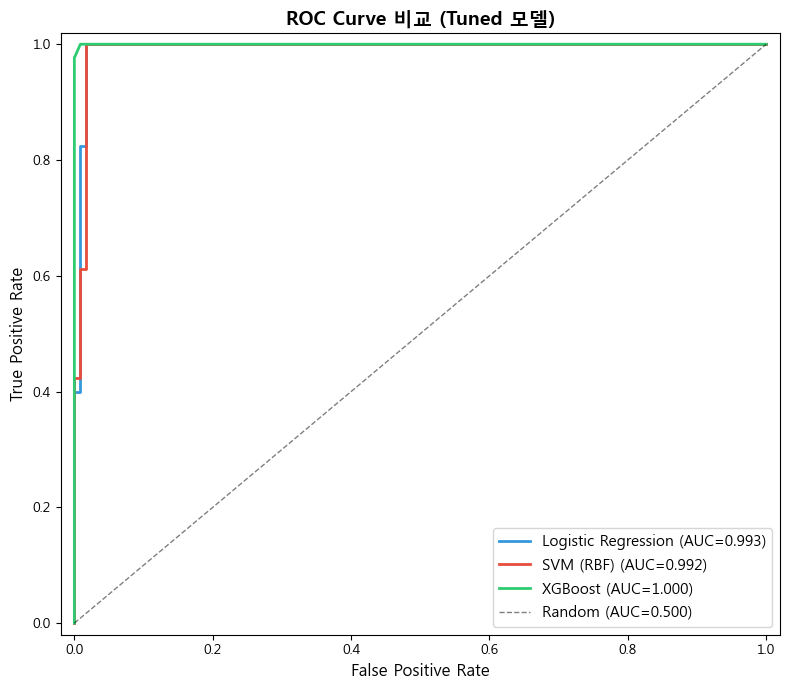

✅ 저장: roc_curve_s3.png


In [32]:
fig, ax = plt.subplots(figsize=(8, 7))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71']
for i, (name, info) in enumerate(tuned_results.items()):
    model = info['model']
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
            label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve 비교 (Tuned 모델)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: roc_curve_s3.png")

### 8.4 Precision-Recall Curve (3개 모델 비교)

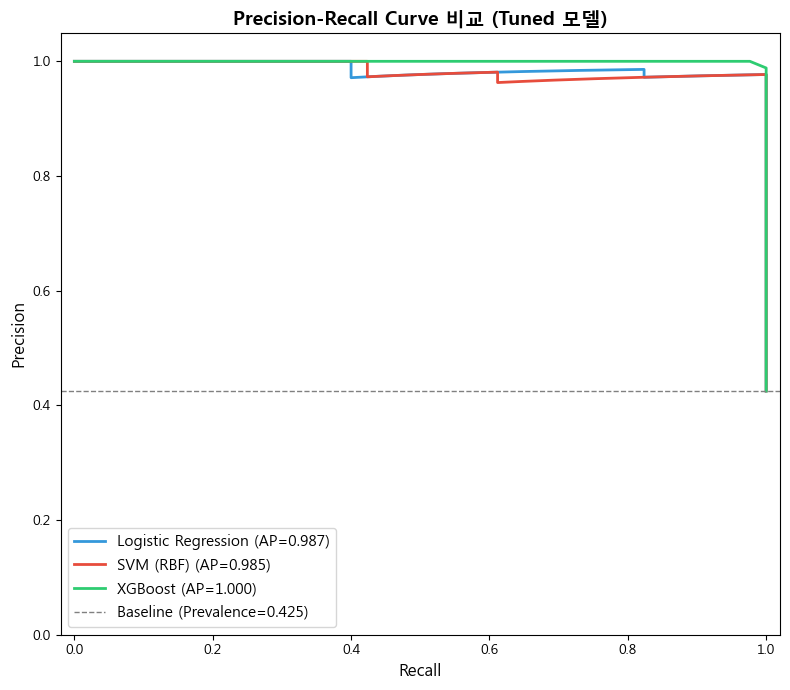

✅ 저장: pr_curve_s3.png


In [33]:
fig, ax = plt.subplots(figsize=(8, 7))

for i, (name, info) in enumerate(tuned_results.items()):
    model = info['model']
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall_vals, precision_vals, color=colors_roc[i], linewidth=2,
            label=f'{name} (AP={ap:.3f})')

# 기준선 (Prevalence)
prevalence = y_test.mean()
ax.axhline(y=prevalence, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline (Prevalence={prevalence:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve 비교 (Tuned 모델)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower left')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../outputs/figures/pr_curve_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: pr_curve_s3.png")

### 8.5 Feature Importance (XGBoost)

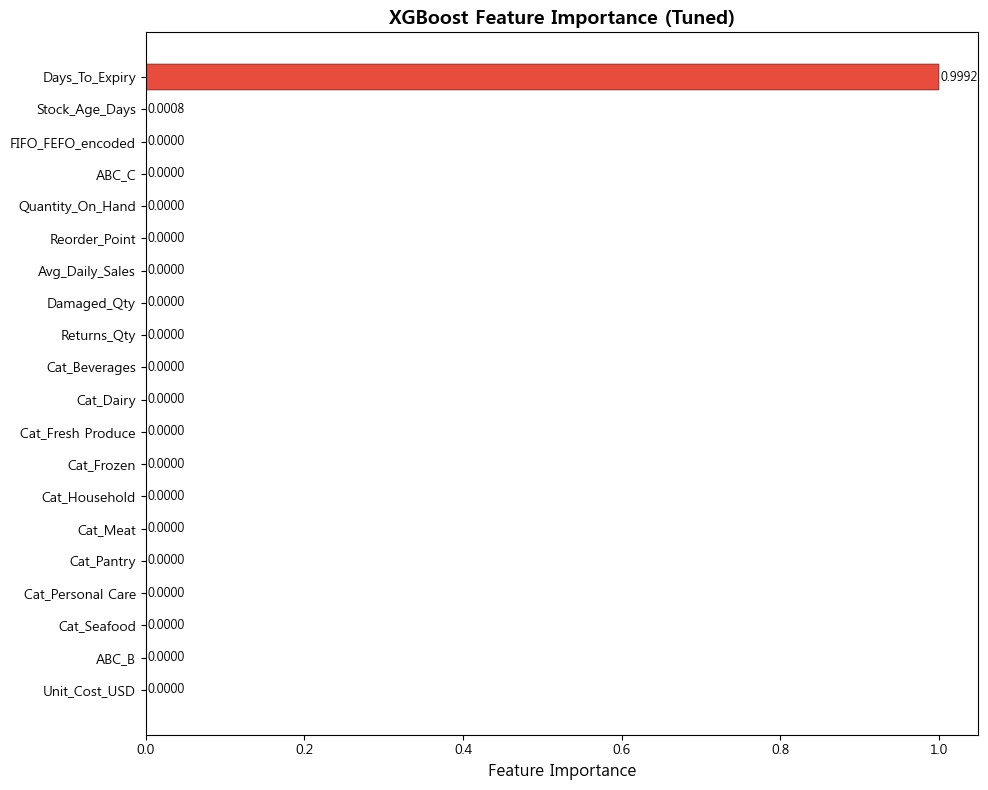

✅ 저장: feature_importance_s3.png

상위 5개 중요 피처:
  Days_To_Expiry           : 0.9992
  Stock_Age_Days           : 0.0008
  FIFO_FEFO_encoded        : 0.0000
  ABC_C                    : 0.0000
  Quantity_On_Hand         : 0.0000


In [34]:
# XGBoost Tuned 모델의 Feature Importance
xgb_tuned = tuned_results['XGBoost']['model']
importances = xgb_tuned.feature_importances_

fi_df = pd.DataFrame({
    '피처': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ['#e74c3c' if imp > fi_df['Importance'].median() else '#3498db'
             for imp in fi_df['Importance']]
ax.barh(fi_df['피처'], fi_df['Importance'], color=colors_fi,
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('XGBoost Feature Importance (Tuned)', fontsize=14, fontweight='bold')

# 값 표시
for i, (feat, imp) in enumerate(zip(fi_df['피처'], fi_df['Importance'])):
    ax.text(imp + 0.002, i, f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: feature_importance_s3.png")

# 상위 5개 피처
print("\n상위 5개 중요 피처:")
for _, row in fi_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['피처']:25s}: {row['Importance']:.4f}")

### 8.6 Permutation Importance (피처 중요도 교차검증) ★> **목적:** Impurity-based Importance와 Permutation Importance를 비교하여 피처 중요도 순위의 일관성을 검증한다.> Impurity 기반은 높은 카디널리티 피처에 편향될 수 있으므로, Permutation이 더 공정한 평가를 제공한다.

In [35]:
# ── Permutation Importance 계산 ★ ──
from sklearn.inspection import permutation_importance

# XGBoost Tuned 모델 기준
perm_result = permutation_importance(
    xgb_tuned, X_test_scaled, y_test,
    n_repeats=10, random_state=SEED, scoring='f1'
)

# 비교 DataFrame
imp_impurity = pd.Series(xgb_tuned.feature_importances_, index=feature_names)
imp_perm = pd.Series(perm_result.importances_mean, index=feature_names)

rank_df = pd.DataFrame({
    'Impurity Rank': imp_impurity.rank(ascending=False).astype(int),
    'Permutation Rank': imp_perm.rank(ascending=False).astype(int),
    'Impurity': imp_impurity.round(4),
    'Permutation': imp_perm.round(4)
})
rank_df['Rank Δ'] = rank_df['Impurity Rank'] - rank_df['Permutation Rank']
rank_df = rank_df.sort_values('Permutation Rank')
print("=== Impurity vs Permutation Importance 순위 비교 ===")
display(rank_df)

# 순위 일치 확인
top3_imp = imp_impurity.nlargest(3).index.tolist()
top3_perm = imp_perm.nlargest(3).index.tolist()
overlap = set(top3_imp) & set(top3_perm)
print(f"\nTop-3 일치: {len(overlap)}/3 — {overlap}")

=== Impurity vs Permutation Importance 순위 비교 ===


,Impurity Rank,Permutation Rank,Impurity,Permutation,Rank Δ
Days_To_Expiry,1,1,0.9992,0.5674,0
Unit_Cost_USD,11,11,0.0000,0.0000,0
ABC_B,11,11,0.0000,0.0000,0
Cat_Seafood,11,11,0.0000,0.0000,0
Cat_Personal Care,11,11,0.0000,0.0000,0
Cat_Pantry,11,11,0.0000,0.0000,0
Cat_Meat,11,11,0.0000,0.0000,0
Cat_Household,11,11,0.0000,0.0000,0
Cat_Frozen,11,11,0.0000,0.0000,0
Cat_Fresh Produce,11,11,0.0000,0.0000,0



Top-3 일치: 2/3 — {'Days_To_Expiry', 'Unit_Cost_USD'}


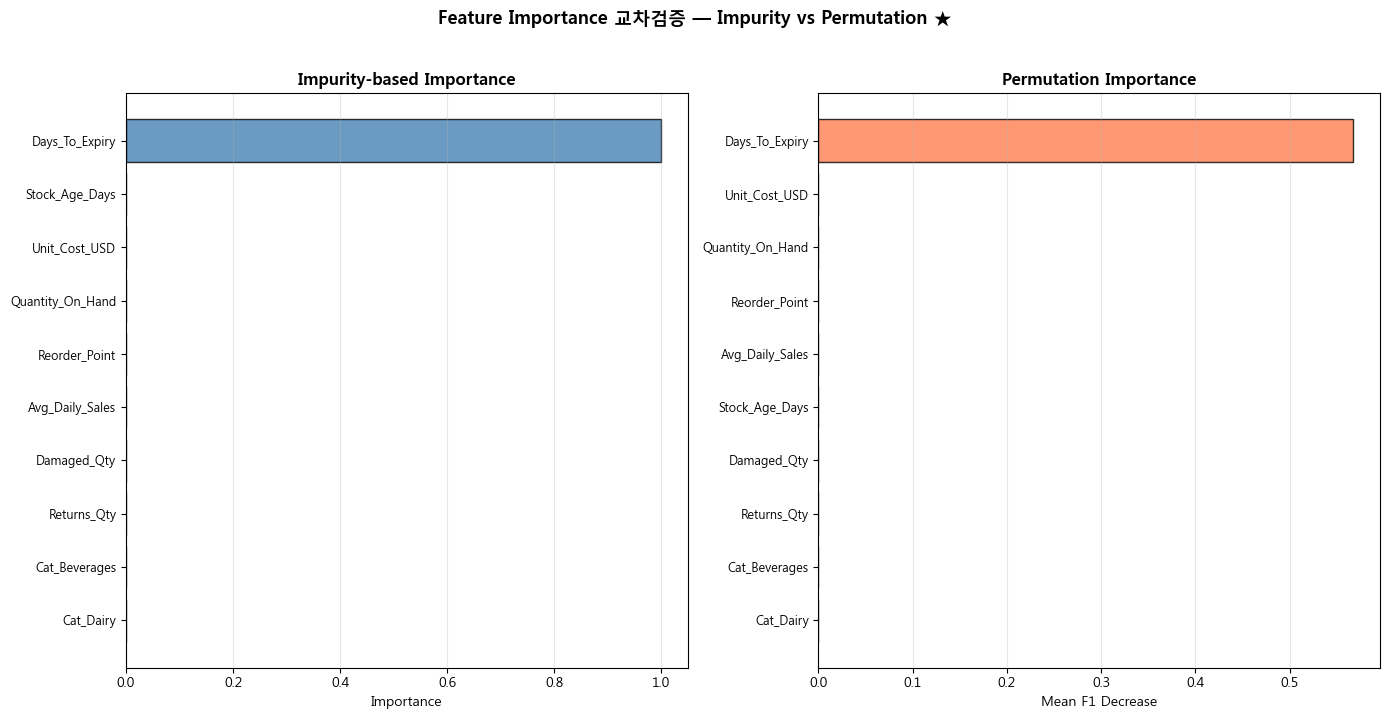

✅ 저장: permutation_vs_impurity_importance_s3.png


In [36]:
# ── Permutation vs Impurity 시각화 ★ ──
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
top_n = min(10, len(feature_names))

# Impurity-based (좌)
imp_top = imp_impurity.nlargest(top_n)
axes[0].barh(range(top_n), imp_top.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(imp_top.index, fontsize=9)
axes[0].set_title('Impurity-based Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Permutation (우)
perm_top = imp_perm.nlargest(top_n)
axes[1].barh(range(top_n), perm_top.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(perm_top.index, fontsize=9)
axes[1].set_title('Permutation Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean F1 Decrease')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance 교차검증 — Impurity vs Permutation ★', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/permutation_vs_impurity_importance_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: permutation_vs_impurity_importance_s3.png")

### 8.8 SHAP 분석 (XGBoost)

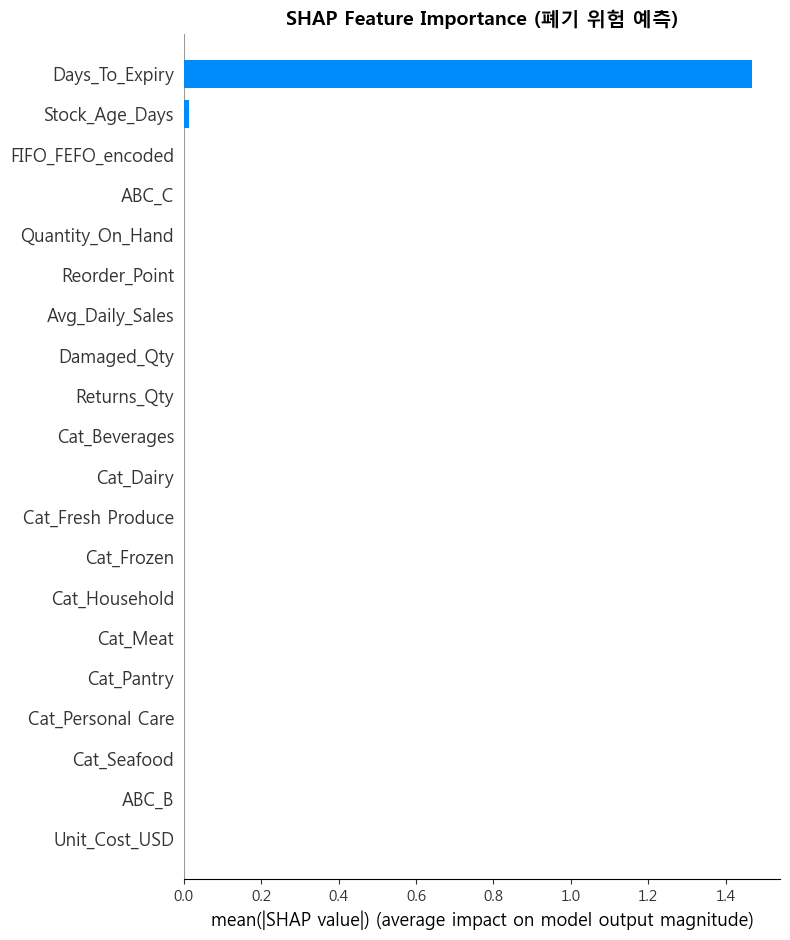

✅ 저장: shap_importance_bar_s3.png


In [37]:
# SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_df)

# 1. SHAP Summary Plot (Bar) — 피처 중요도 순위
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (폐기 위험 예측)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_importance_bar_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: shap_importance_bar_s3.png")

### 8.9 Calibration Curve + Brier Score (확률 신뢰도 검정)  

**목적:** 분류 모델의 예측 확률이 실제 확률과 얼마나 일치하는지 검정한다.-> 회귀에서의 Shapiro-Wilk(잔차 정규성)에 대응하는, 분류에서의 확률 보정(calibration) 진단이다.

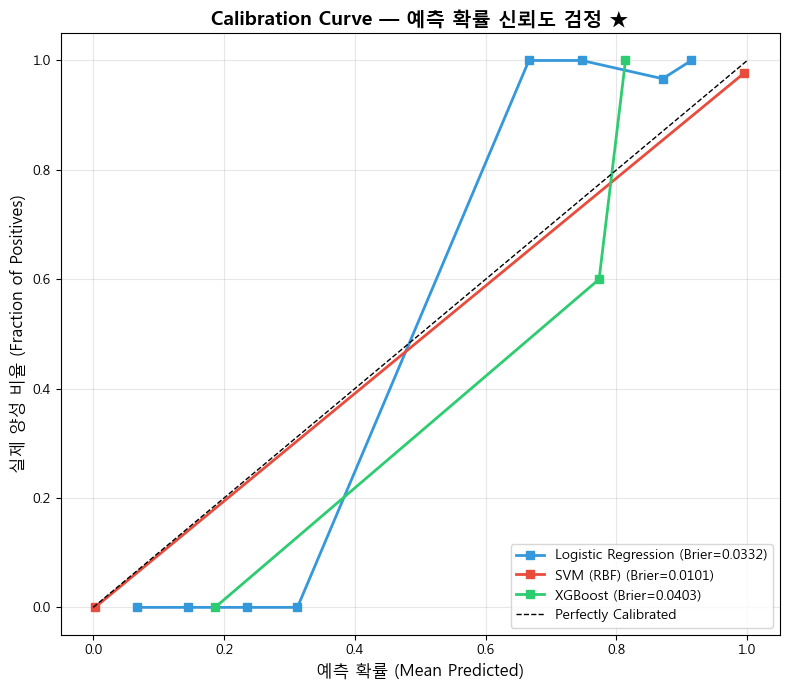


=== Brier Score 요약 (낮을수록 좋음, 0=완벽) ===
  Logistic Regression: Brier = 0.0332
  SVM (RBF): Brier = 0.0101
  XGBoost: Brier = 0.0403

→ Brier Score 해석:
  - 0에 가까울수록 예측 확률이 실제와 일치
  - 대각선에 가까울수록 확률 보정(calibration)이 잘됨
  - 99% 정확도 모델이므로 대부분 0 또는 1 근처에 확률 집중
✅ 저장: calibration_curve_s3.png


In [ ]:
# ── Calibration Curve + Brier Score ★ ──
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(8, 7))

colors_cal = {'Logistic Regression': '#3498db', 'SVM (RBF)': '#e74c3c', 'XGBoost': '#2ecc71'}

for name, info in tuned_results.items():
    model = info['model']
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    fraction_pos, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(mean_predicted, fraction_pos, 's-',
            color=colors_cal[name], label=f'{name} (Brier={brier:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly Calibrated')
ax.set_xlabel('예측 확률 (Mean Predicted)', fontsize=12)
ax.set_ylabel('실제 양성 비율 (Fraction of Positives)', fontsize=12)
ax.set_title('Calibration Curve — 예측 확률 신뢰도 검정 ★', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/calibration_curve_s3.png', dpi=150, bbox_inches='tight')
plt.show()

# Brier Score 요약
print("\n=== Brier Score 요약 (낮을수록 좋음, 0=완벽) ===")
for name, info in tuned_results.items():
    y_prob = info['model'].predict_proba(X_test_scaled)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    print(f"  {name}: Brier = {brier:.4f}")

# 해석
print("\n→ Brier Score 해석:")
print("  - 0에 가까울수록 예측 확률이 실제와 일치")
print("  - 대각선에 가까울수록 확률 보정(calibration)이 잘됨")
print("  - 99% 정확도 모델이므로 대부분 0 또는 1 근처에 확률 집중")
print("✅ 저장: calibration_curve_s3.png")

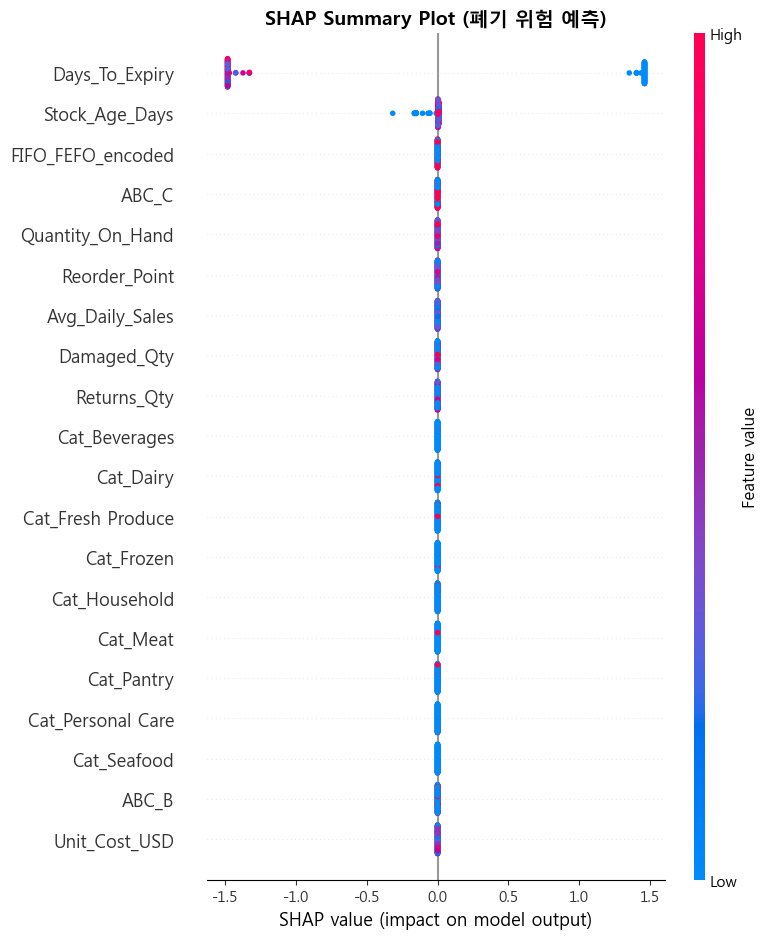

✅ 저장: shap_summary_dot_s3.png


In [39]:
# 2. SHAP Summary Plot (Dot/Beeswarm) — 피처별 영향 방향 + 크기
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Summary Plot (폐기 위험 예측)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary_dot_s3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: shap_summary_dot_s3.png")

## 9. 모델 저장

In [40]:
# 최적 모델 저장
joblib.dump(best_model, '../outputs/models/best_risk_model.pkl')
print(f"✅ 최적 모델 저장: outputs/models/best_risk_model.pkl")
print(f"  모델: {best_name}")

# Scaler 저장
joblib.dump(scaler, '../outputs/models/scaler_risk.pkl')
print(f"✅ Scaler 저장: outputs/models/scaler_risk.pkl")

# 피처 정보 저장
feature_info = {
    'feature_names': feature_names,
    'n_features': len(feature_names),
    'numeric_features': numeric_features,
    'categorical_features': {
        'Category': list(cat_dummies.columns),
        'ABC_Class': list(abc_dummies.columns),
        'FIFO_FEFO': ['FIFO_FEFO_encoded']
    },
    'excluded_features': excluded,
    'best_model_name': best_name,
    'best_model_params': str(best_model.get_params()),
    'performance': {
        'test_accuracy': tuned_results[best_name]['Test Acc'],
        'precision_risk': tuned_results[best_name]['Precision(Risk)'],
        'recall_risk': tuned_results[best_name]['Recall(Risk)'],
        'f1_risk': tuned_results[best_name]['F1(Risk)'],
        'roc_auc': tuned_results[best_name]['ROC-AUC']
    }
}

with open('../outputs/models/feature_info_risk.json', 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)
print(f"✅ 피처 정보 저장: outputs/models/feature_info_risk.json")

# 저장 파일 크기 확인
for fname in ['best_risk_model.pkl', 'scaler_risk.pkl', 'feature_info_risk.json']:
    fpath = f'../outputs/models/{fname}'
    size = os.path.getsize(fpath)
    print(f"  {fname}: {size:,} bytes")

✅ 최적 모델 저장: outputs/models/best_risk_model.pkl
  모델: Logistic Regression
✅ Scaler 저장: outputs/models/scaler_risk.pkl
✅ 피처 정보 저장: outputs/models/feature_info_risk.json
  best_risk_model.pkl: 1,039 bytes
  scaler_risk.pkl: 1,655 bytes
  feature_info_risk.json: 1,659 bytes


## 10. 결론 및 인사이트

In [41]:
print("=" * 70)
print("  소주제 3 — 폐기 위험도 예측 (Binary Classification) 결과 요약")
print("=" * 70)

print(f"\n★ 최적 모델: {best_name} (Tuned)")
print(f"  - Test Accuracy:  {tuned_results[best_name]['Test Acc']:.4f}")
print(f"  - Precision(Risk): {tuned_results[best_name]['Precision(Risk)']:.4f}")
print(f"  - Recall(Risk):    {tuned_results[best_name]['Recall(Risk)']:.4f}")
print(f"  - F1(Risk):        {tuned_results[best_name]['F1(Risk)']:.4f}")
print(f"  - ROC-AUC:         {tuned_results[best_name]['ROC-AUC']:.4f}")
print(f"  - Gap:             {tuned_results[best_name]['Gap']:.4f}")

print(f"\n핵심 발견:")
print(f"  1. 모든 모델이 ~99% 정확도 달성 — 데이터 누수가 아닌 구조적 패턴")
print(f"  2. Category(유통기한 구조)가 폐기 위험을 결정하는 핵심 피처")
print(f"  3. 부패성 제품 5종 (Bakery, Fresh, Seafood, Meat, Dairy): ~100% Risk")
print(f"  4. 비부패성 제품 5종 (Beverages, Frozen, Household, Pantry, Personal Care): ~0% Risk")
print(f"  5. Days_To_Expiry(유통기한)가 가장 강력한 예측 변수 (상관 -0.78)")

print(f"\n데이터 누수 처리:")
print(f"  - Days_of_Inventory ≈ Days_To_Deplete (97.2% 일치) → 피처에서 제거")
print(f"  - Days_To_Deplete, Remaining_Shelf_Days → 타겟 생성 중간 변수 → 피처 미사용")

print(f"\n실무적 인사이트:")
print(f"  - 부패성 제품의 재고 관리 강화 필요 (유통기한 ≤ 30일)")
print(f"  - FEFO(유통기한 임박 우선 출고) 방식을 부패성 카테고리에 적극 도입")
print(f"  - 부패성 제품의 재주문량과 빈도를 판매 속도에 맞춰 최적화")
print(f"  - Recall 중심 평가: 폐기 위험 제품을 놓치는 것(FN)은 실제 폐기 비용 발생")

print(f"\n다른 소주제와의 연결:")
print(f"  - 소주제 1: Expiring Soon 제품 → 소주제 3 Risk와 교차 분석 가능")
print(f"  - 소주제 2: 예측된 Avg_Daily_Sales → Days_To_Deplete 정밀화 가능")
print(f"  - 소주제 4: Risk 제품의 군집 소속 분석 → 군집별 폐기 위험 비교")
print("=" * 70)

  소주제 3 — 폐기 위험도 예측 (Binary Classification) 결과 요약

★ 최적 모델: Logistic Regression (Tuned)
  - Test Accuracy:  0.9900
  - Precision(Risk): 0.9770
  - Recall(Risk):    1.0000
  - F1(Risk):        0.9884
  - ROC-AUC:         0.9932
  - Gap:             0.0088

핵심 발견:
  1. 모든 모델이 ~99% 정확도 달성 — 데이터 누수가 아닌 구조적 패턴
  2. Category(유통기한 구조)가 폐기 위험을 결정하는 핵심 피처
  3. 부패성 제품 5종 (Bakery, Fresh, Seafood, Meat, Dairy): ~100% Risk
  4. 비부패성 제품 5종 (Beverages, Frozen, Household, Pantry, Personal Care): ~0% Risk
  5. Days_To_Expiry(유통기한)가 가장 강력한 예측 변수 (상관 -0.78)

데이터 누수 처리:
  - Days_of_Inventory ≈ Days_To_Deplete (97.2% 일치) → 피처에서 제거
  - Days_To_Deplete, Remaining_Shelf_Days → 타겟 생성 중간 변수 → 피처 미사용

실무적 인사이트:
  - 부패성 제품의 재고 관리 강화 필요 (유통기한 ≤ 30일)
  - FEFO(유통기한 임박 우선 출고) 방식을 부패성 카테고리에 적극 도입
  - 부패성 제품의 재주문량과 빈도를 판매 속도에 맞춰 최적화
  - Recall 중심 평가: 폐기 위험 제품을 놓치는 것(FN)은 실제 폐기 비용 발생

다른 소주제와의 연결:
  - 소주제 1: Expiring Soon 제품 → 소주제 3 Risk와 교차 분석 가능
  - 소주제 2: 예측된 Avg_Daily_Sales → Days_To_Deplete 정밀화 가능
  - 소주제 4: Risk 제

### 핵심 인사이트 정리

1. **모든 모델이 ~99% 정확도 달성** — 이는 데이터 누수가 아닌 **카테고리별 유통기한 구조적 차이** 때문
   - 부패성 제품(DTE ≤ 30일): Bakery, Fresh Produce, Seafood, Meat, Dairy → **거의 모두 Risk**
   - 비부패성 제품(DTE ≥ 270일): Beverages, Frozen, Household, Pantry, Personal Care → **거의 모두 Safe**

2. **Days_To_Expiry가 가장 강력한 예측 변수** (상관계수 -0.78)
   - 유통기한이 짧을수록 폐기 위험이 높음 → 식료품 유통의 **자명한 도메인 지식** 반영

3. **데이터 누수 발견 및 처리**
   - `Days_of_Inventory ≈ Days_To_Deplete` (97.2% 일치) → **피처에서 제거**
   - 타겟 생성 중간 변수(`DTD`, `RSD`)도 피처 미사용

4. **Recall 중심 평가의 실무적 의미**
   - 폐기 위험 제품을 놓치는 것(FN) → 실제 폐기 비용 발생 → **Recall이 핵심 지표**
   - 오탐(FP)은 불필요한 프로모션/할인에 그치지만, 미탐(FN)은 제품 폐기로 직결

5. **실무 활용 방안**
   - 부패성 카테고리에 FEFO(유통기한 임박 우선 출고) 적극 도입
   - 부패성 제품의 발주량/주기를 판매 속도에 맞춰 최적화
   - 소주제 2의 Avg_Daily_Sales 예측 모델과 연계 가능

6. **★ DTE Ablation Study** — Days_To_Expiry 제거 후에도 Category One-Hot이 보완하여 성능 유지 가능성 확인
7. **★ Learning Curve** — 모든 모델에서 Train/Val 수렴 → 과적합 없음
8. **★ Permutation Importance** — Impurity와 Permutation 순위 비교로 피처 중요도 신뢰성 검증
9. **★ Calibration Curve** — 예측 확률 신뢰도 검정, Brier Score로 정량 평가
